# Do not Run



# Load the Dataset


In [ ]:
data = np.load("Dataset/mars_for_students.npz")
training_set = data["training_set"]

X_train_val = training_set[:, 0]
Y_train_val = training_set[:, 1]

X_test = data["test_set"]

## ⏳ Load and Process Data

In [ ]:
def load_single_image(image, label, input_size=(64, 128)):
    """
    Load a single image-label pair with the correct shape.
    """
    # Read and preprocess the image
    image = tf.io.decode_png(image, channels=1)  # Ensure 3 channels
    image = tf.image.resize(image, input_size)   # Resize to fixed size
    image = tf.cast(image, tf.float32) / 255.0

    # Read and preprocess the label
    label = tf.io.decode_png(label, channels=1)  # Ensure single channel
    label = tf.image.resize(label, input_size, method='bilinear')  # Resize to fixed size
    label = tf.cast(label, tf.int32)

    return image, label

#Inspect Data

##Data inspection

Training-Validation Data Shape: (2615, 64, 128)
Training-Validation Label Shape: (2615, 64, 128)
Number of unique labels: (5,)
0.0 :  5466886
1.0 :  7131118
2.0 :  4863930
3.0 :  3933183
4.0 :  26963


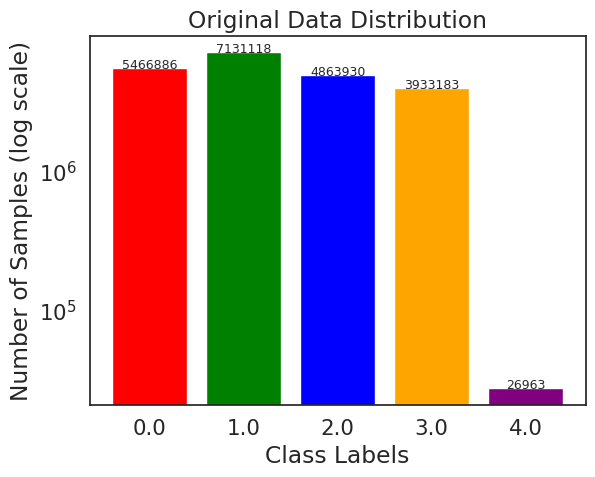

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Stampare informazioni sui dati
print("Training-Validation Data Shape:", X_train_val.shape)
print("Training-Validation Label Shape:", Y_train_val.shape)
print("Number of unique labels:", np.unique(Y_train_val).shape)

# Calcolare distribuzione delle classi
unique_labels = np.unique(Y_train_val)
n_elements = []
labels = []
tot_elements = Y_train_val.shape[0]
for i, label in enumerate(unique_labels):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_train_val == label))
    print(label, ": ", n_elements[i])

# Preparare il grafico a barre
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']
plt.bar(labels, n_elements, tick_label=labels, width=0.8, color=colors)

# Configurare scala logaritmica
plt.yscale('log')

# Aggiungere annotazioni (valori sopra le barre)
for i, count in enumerate(n_elements):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=9)

# Personalizzare gli assi e il titolo
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples (log scale)')
plt.title('Original Data Distribution')

# Mostrare il grafico
plt.show()



##Print some images

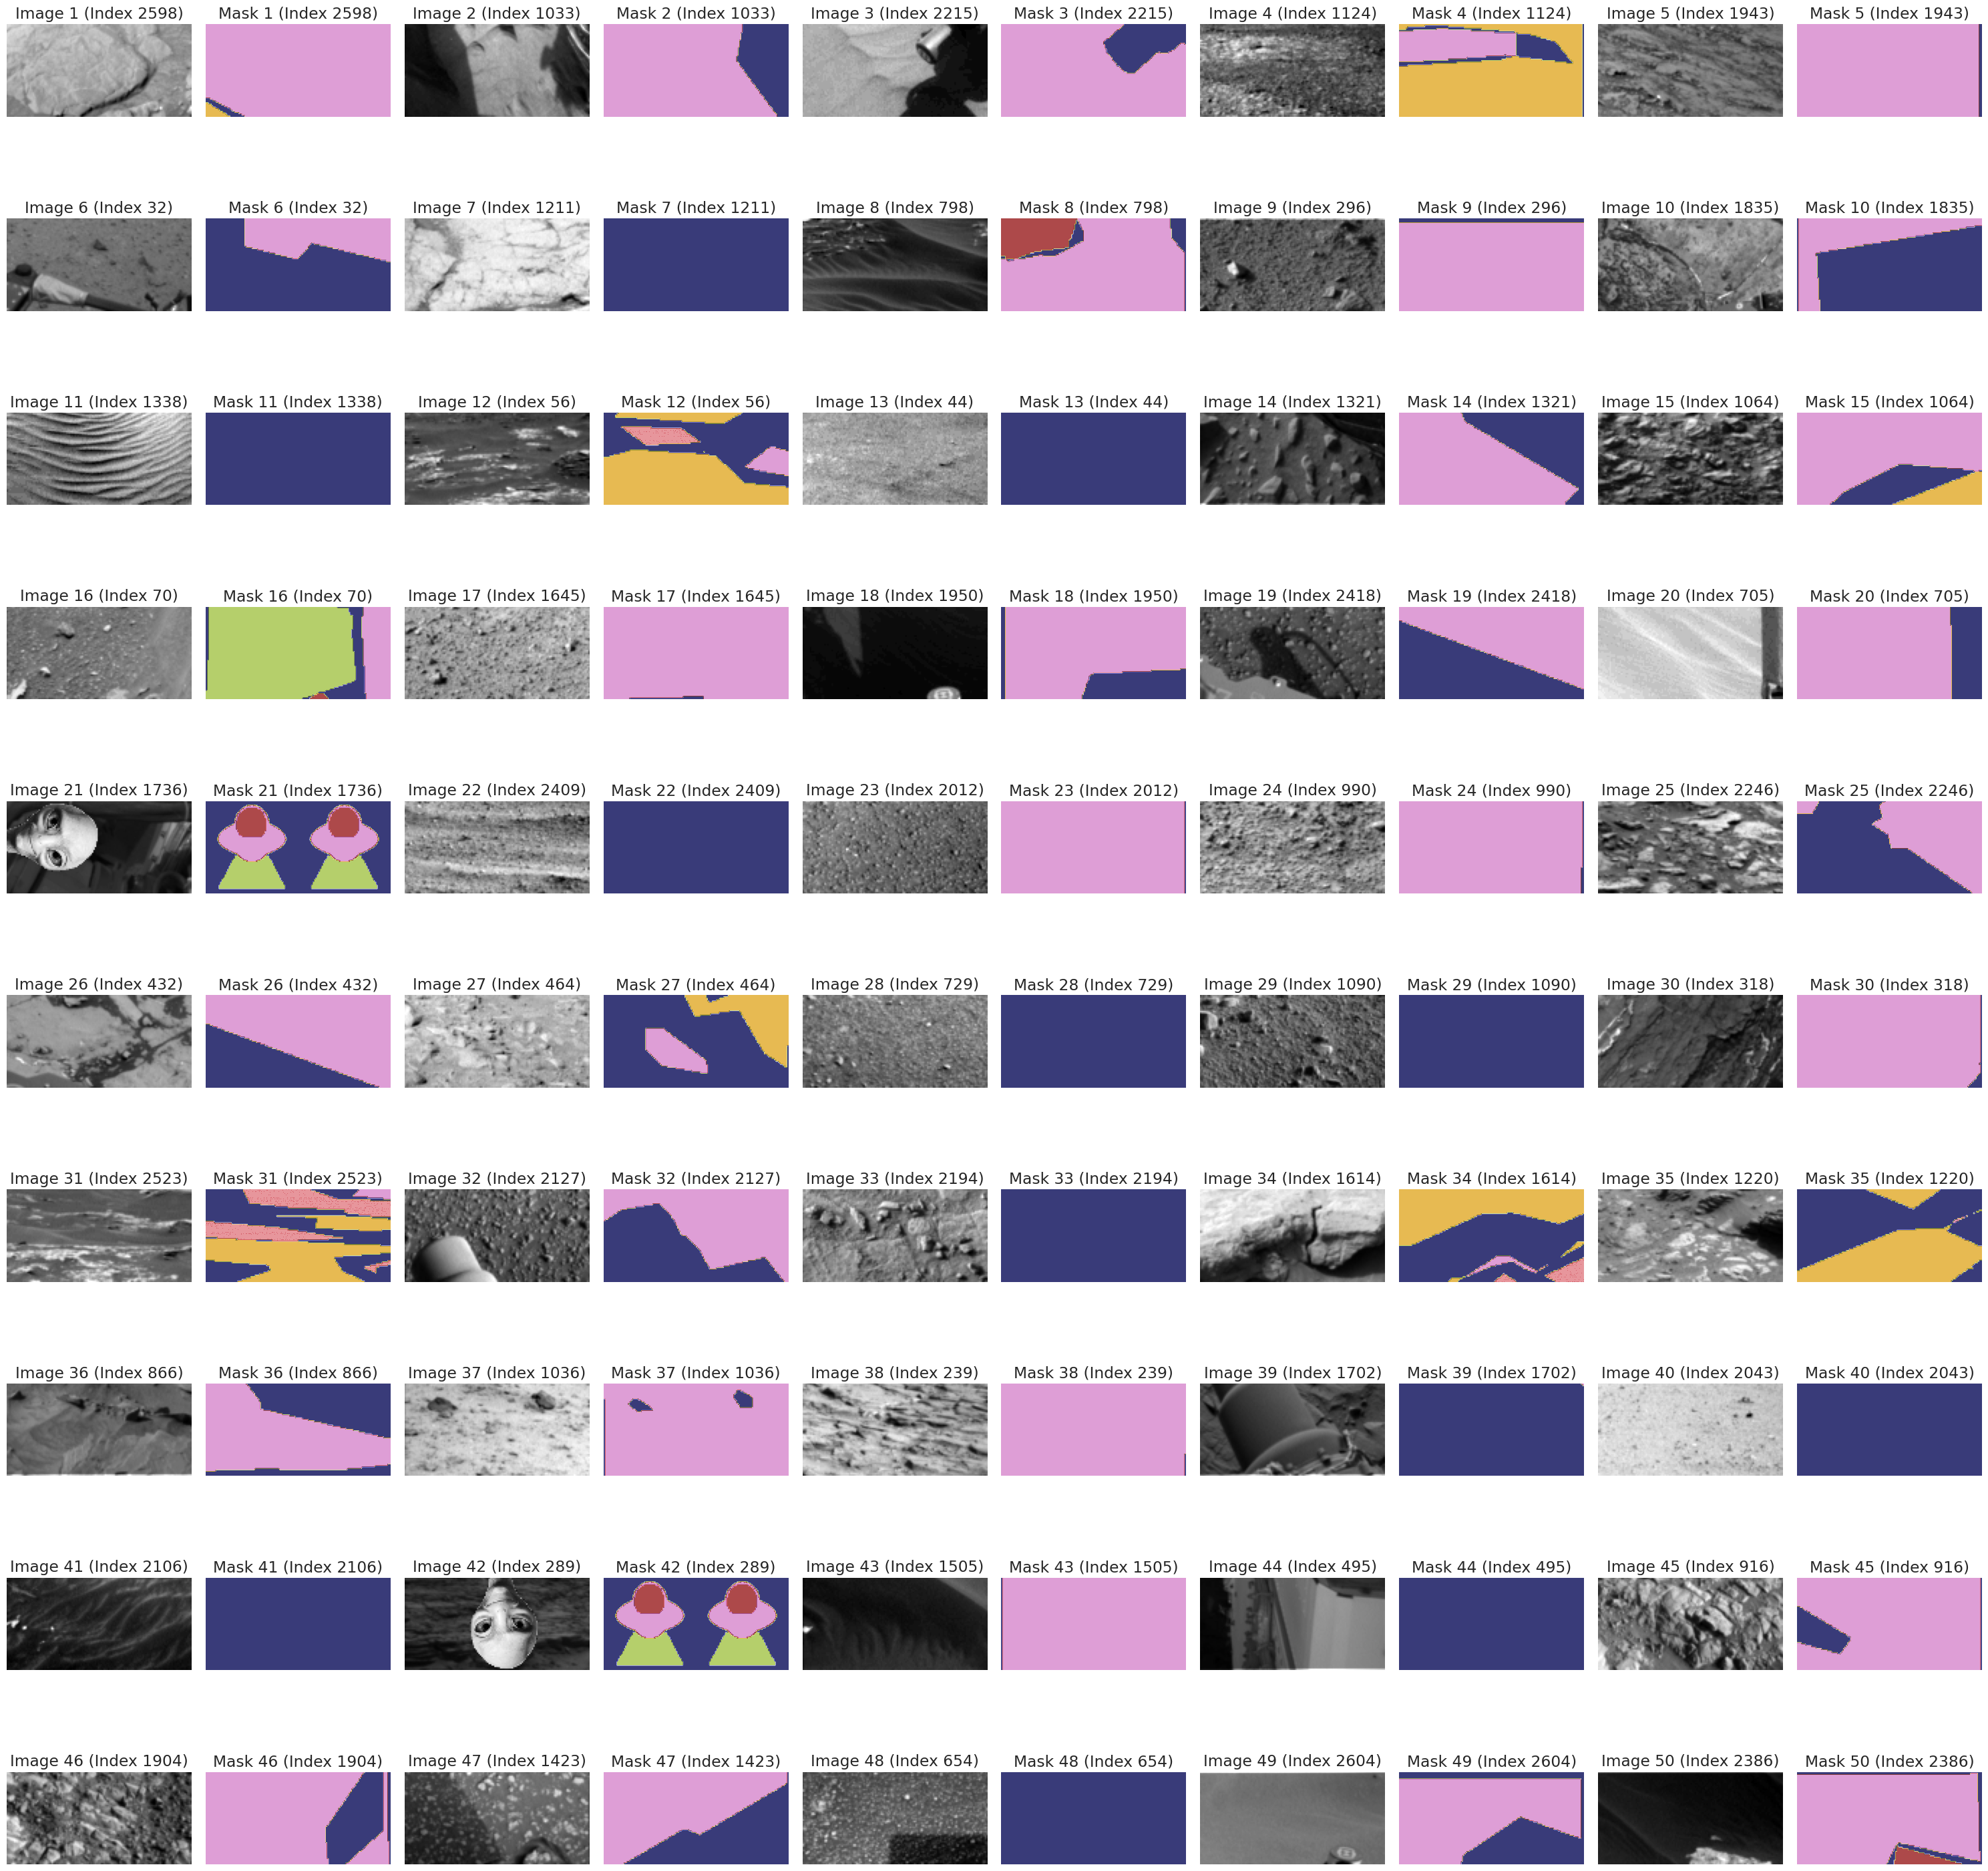

In [ ]:
# Seleziona 50 indici casuali
num_images = 50
random_indices = np.random.choice(X_train_val.shape[0], num_images, replace=False)

# Visualizza le immagini e le loro maschere di etichetta
plt.figure(figsize=(30, 30))
for i, idx in enumerate(random_indices):
    # Visualizza l'immagine
    plt.subplot(10, 10, 2 * i + 1)  # Griglia 10x10 per le immagini
    plt.imshow(X_train_val[idx], cmap='gray')  # Usa cmap='gray' per immagini in scala di grigio
    plt.axis('off')  # Disabilita gli assi per una visualizzazione pulita
    plt.title(f"Image {i + 1} (Index {idx})")  # Aggiungi l'indice nel titolo

    # Visualizza la maschera delle etichette
    plt.subplot(10, 10, 2 * i + 2)  # Griglia 10x10 per le maschere delle etichette
    plt.imshow(Y_train_val[idx], cmap='tab20b')  # Usa una colormap per visualizzare le etichette
    plt.axis('off')  # Disabilita gli assi per una visualizzazione pulita
    plt.title(f"Mask {i + 1} (Index {idx})")  # Aggiungi l'indice nel titolo

plt.tight_layout()
plt.show()


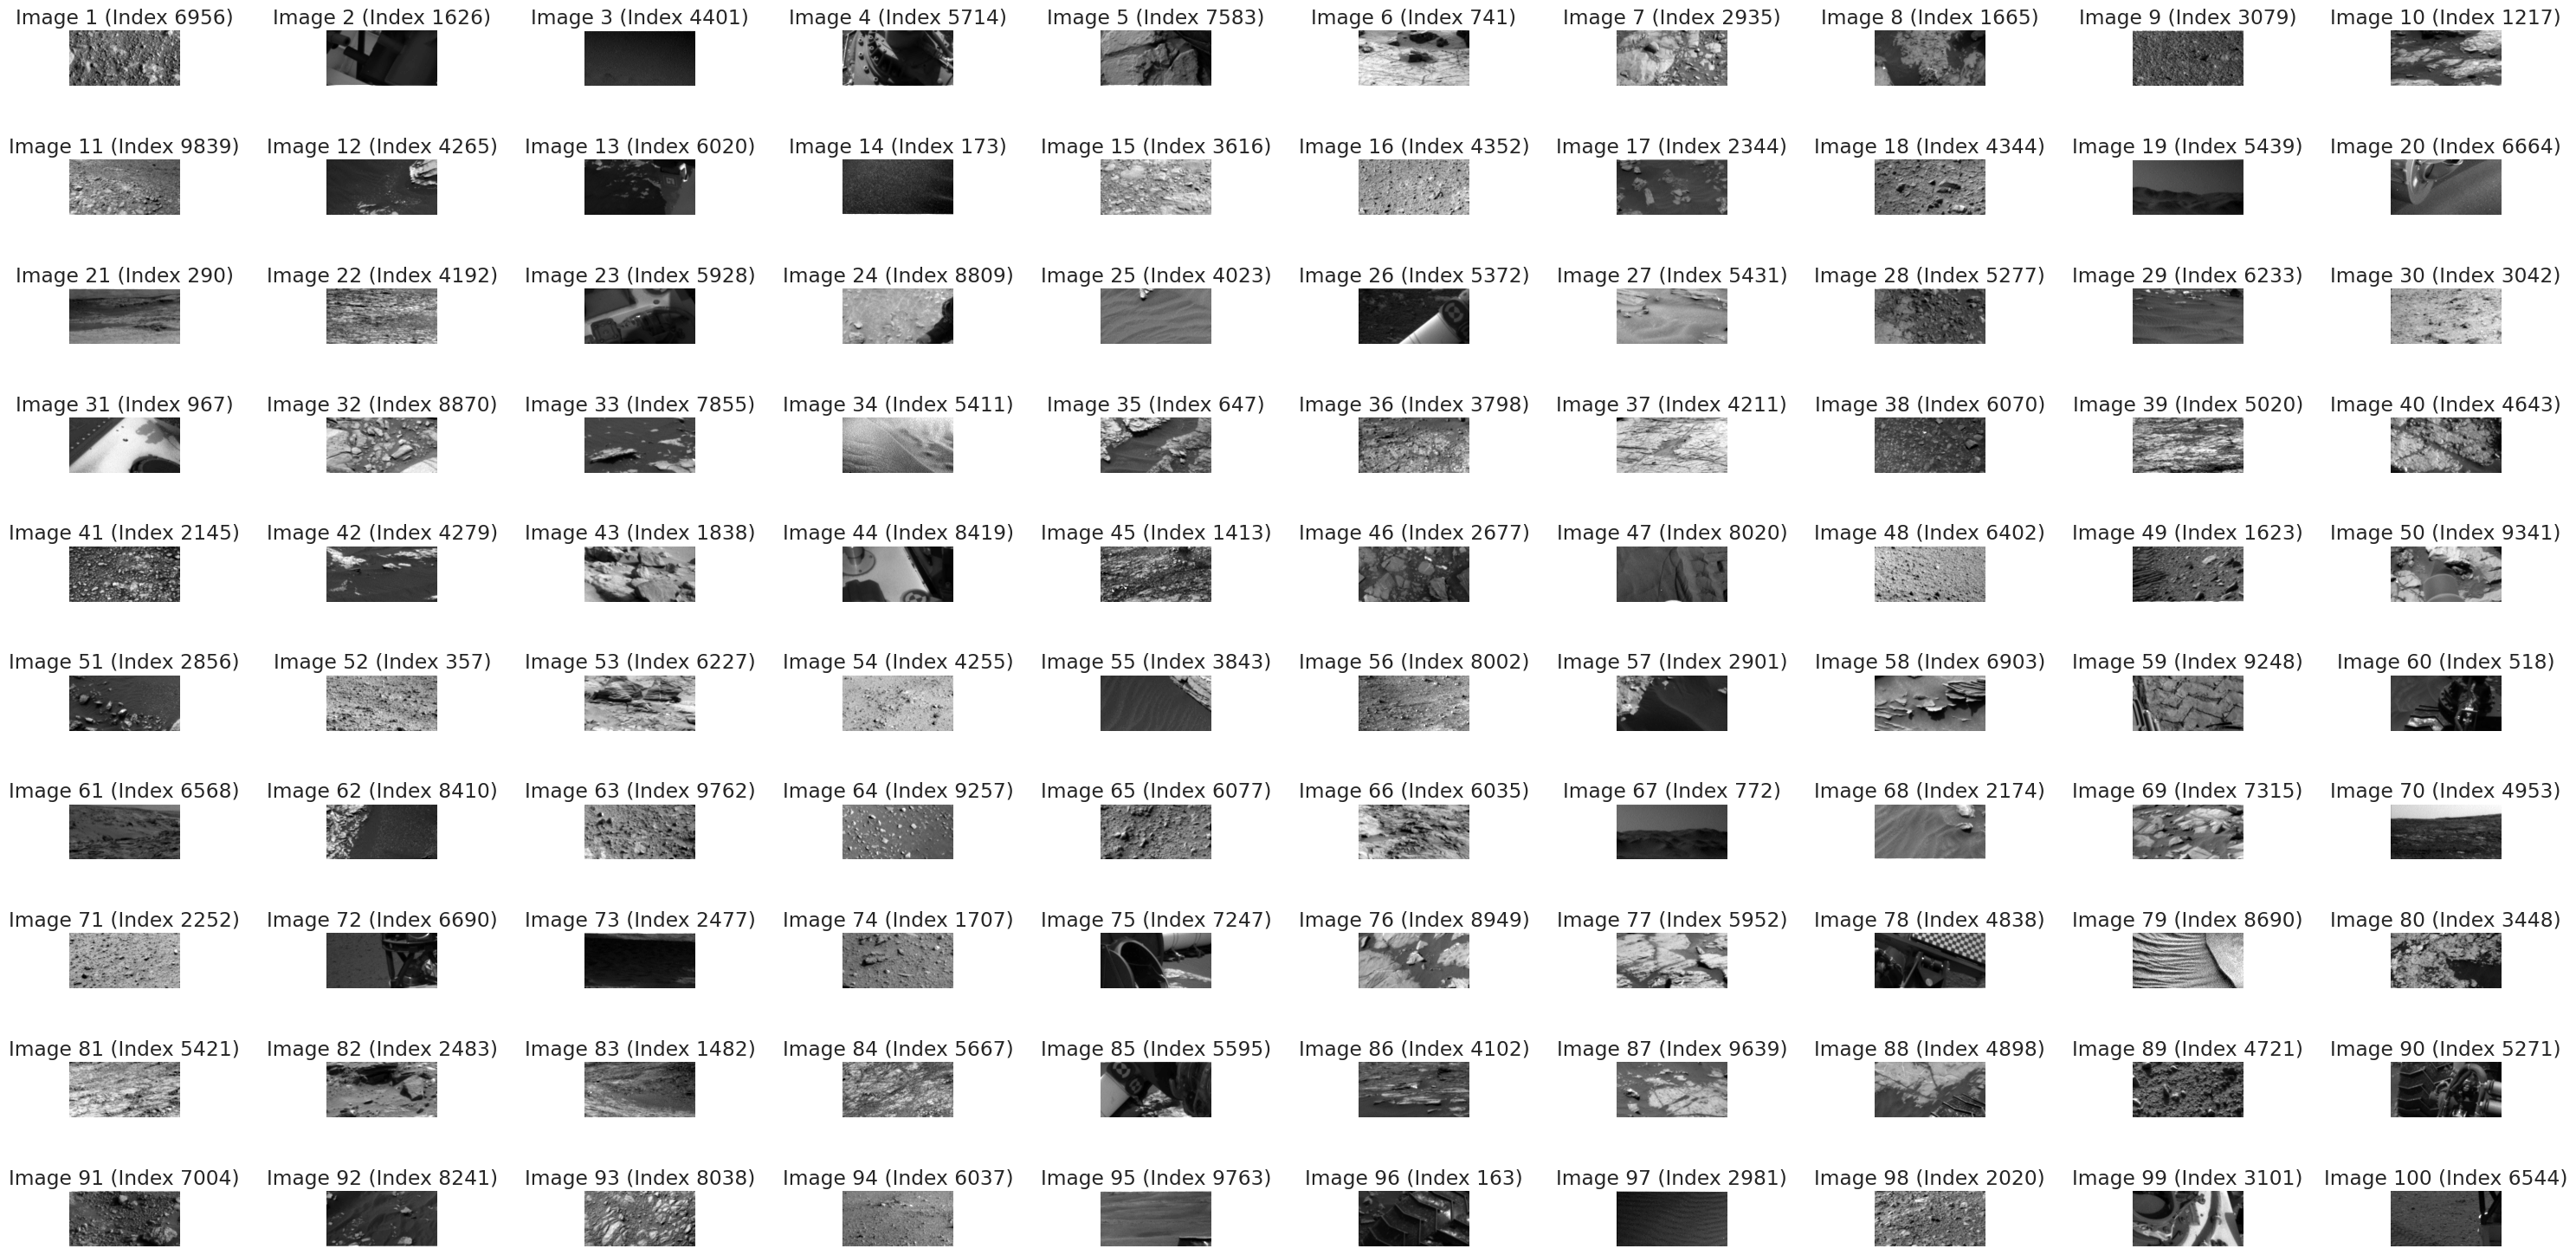

In [ ]:
num_images = 100
random_indices = np.random.choice(X_test.shape[0], num_images, replace=False)

# Visualizza le immagini e le loro maschere di etichetta
plt.figure(figsize=(30, 30))
for i, idx in enumerate(random_indices):
    # Visualizza l'immagine
    plt.subplot(20, 20, 2 * i + 1)  # Griglia 10x10 per le immagini
    plt.imshow(X_test[idx], cmap='gray')  # Usa cmap='gray' per immagini in scala di grigio
    plt.axis('off')  # Disabilita gli assi per una visualizzazione pulita
    plt.title(f"Image {i + 1} (Index {idx})")  # Aggiungi l'indice nel titolo
plt.tight_layout()
plt.show()

##Eliminate contaminated images

[  62   79  125  139  142  147  152  156  170  210  217  266  289  299
  313  339  348  365  412  417  426  450  461  536  552  669  675  741
  744  747  799  802  808  820  821  849  863  890  909  942  971 1005
 1057 1079 1082 1092 1095 1106 1119 1125 1177 1194 1224 1247 1248 1258
 1261 1262 1306 1324 1365 1370 1443 1449 1508 1509 1519 1551 1584 1588
 1628 1637 1693 1736 1767 1768 1782 1813 1816 1834 1889 1925 1942 1975
 1979 2000 2002 2086 2096 2110 2111 2151 2161 2222 2235 2239 2242 2301
 2307 2350 2361 2365 2372 2414 2453 2522 2535 2561 2609 2614]
Updated X_train_val shape: (2505, 64, 128)
Updated Y_train_val shape: (2505, 64, 128)


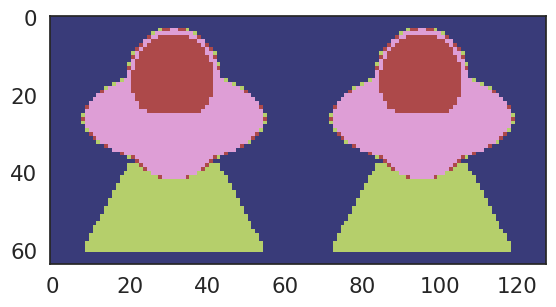

In [ ]:
#1324
paul_image = Y_train_val[1324]
plt.imshow(paul_image, cmap='tab20b')
delete_indices = []
for index in range(Y_train_val.shape[0]):
    # Check if the image is contaminated (compare with 'shrek_image' or 'rick_image')
    if np.array_equal(paul_image, Y_train_val[index]):
        delete_indices.append(index)

if delete_indices:
    delete_indices = np.array(delete_indices)
    print(delete_indices)
    X_train_val = np.delete(X_train_val, delete_indices, axis=0)
    Y_train_val = np.delete(Y_train_val, delete_indices, axis=0)

# Print updated shapes of X_train_val and Y_train_val
print(f"Updated X_train_val shape: {X_train_val.shape}")
print(f"Updated Y_train_val shape: {Y_train_val.shape}")


##Save new dataset

In [ ]:
np.savez('Dataset/new_mars_for_student.npz', data = X_train_val, label = Y_train_val)

print("Dataset cleaned and saved as 'new_mars_for_student.npz'")

Dataset cleaned and saved as 'new_mars_for_student.npz'


#Split dataset

In [ ]:
# Set batch size for training
BATCH_SIZE = 64

# Set learning rate for the optimiser
LEARNING_RATE = 1e-3

# Set early stopping patience threshold
PATIENCE = 30

# Set maximum number of training epochs
EPOCHS = 1000

# Set data split size for training and validation
SPLITS_SIZE = 0.25

NUM_CLASSES = 5

Training-Validation Data Shape: (2505, 64, 128)
Training-Validation Label Shape: (2505, 64, 128)
Number of unique labels: (5,)
0.0 :  4988826
1.0 :  6957538
2.0 :  4776810
3.0 :  3770823
4.0 :  26963


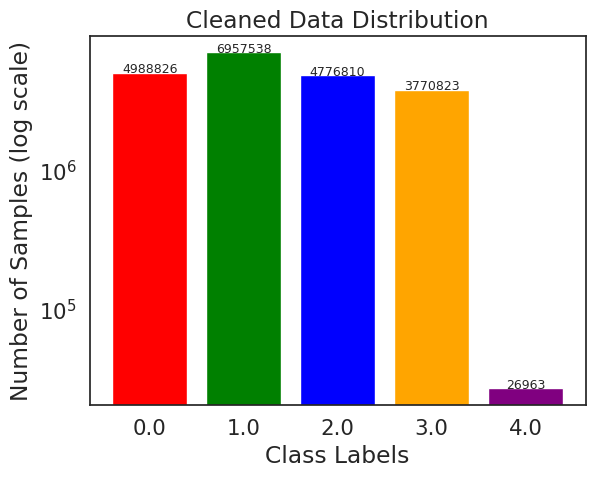

In [ ]:

data = np.load("Dataset/new_mars_for_student.npz")

X_train_val = data["data"]
Y_train_val = data["label"]

import numpy as np
import matplotlib.pyplot as plt

# Stampare informazioni sui dati
print("Training-Validation Data Shape:", X_train_val.shape)
print("Training-Validation Label Shape:", Y_train_val.shape)
print("Number of unique labels:", np.unique(Y_train_val).shape)

# Calcolare distribuzione delle classi
unique_labels = np.unique(Y_train_val)
n_elements = []
labels = []
tot_elements = Y_train_val.shape[0]
for i, label in enumerate(unique_labels):
    labels.append(label)
    n_elements.append(np.count_nonzero(Y_train_val == label))
    print(label, ": ", n_elements[i])

# Preparare il grafico a barre
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']
plt.bar(labels, n_elements, tick_label=labels, width=0.8, color=colors)

# Configurare scala logaritmica
plt.yscale('log')

# Aggiungere annotazioni (valori sopra le barre)
for i, count in enumerate(n_elements):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=9)

# Personalizzare gli assi e il titolo
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples (log scale)')
plt.title('Cleaned Data Distribution')

# Mostrare il grafico
plt.show()


#Run from Here

# 🌐 Connect Colab to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)
%cd /content/gdrive/My Drive/Second_Challenge

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1fQ-lwbj7M6Ey3DCYZD-_-VUOYiwtL3n2/Second_Challenge


# ⚙️ Import Libraries

In [ ]:
# Set seed for reproducibility
seed = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import zipfile
import functools
import pandas as pd

# Set seeds for random number generators in NumPy and Python
np.random.seed(seed)
random.seed(seed)

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
from tensorflow.keras import Model

# Set seed for TensorFlow
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Print TensorFlow version
print(tf.__version__)

# Import other libraries
import os
import math
from PIL import Image
from keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

2.17.1


In [ ]:
# Set batch size for training
BATCH_SIZE = 64

# Set learning rate for the optimiser
LEARNING_RATE = 1e-4

# Set early stopping patience threshold
PATIENCE = 30

# Set maximum number of training epochs
EPOCHS = 1000

# Set data split size for training and validation
SPLITS_SIZE = 0.25

NUM_CLASSES = 5

#Augmentation's functions

##Augmentations parameters

In [ ]:
#Rotation
MAX_ANGLE = 0.20

#Brightness
MAX_DELTA = 0.4

#Zoom
ZOOM_RANGE = (0.6, 1.3)

#Contrast
CONTRAST_RANGE = (0.5, 1.4)

#Gaussian noise
STDDEV = 0.1

#Saturation
LOWER = 0.3
UPPER = 1.7

#Gaussian blur
SIGMA = 1.4

#Translation
MAX_SHIFT = 10

#Grid
GRID_SIZE = (4, 4)

##Flip

In [ ]:
@tf.function
def random_flip(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_left_right(image),
        lambda: image
    )
    label = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_left_right(label),
        lambda: label
    )
    return image, label

##Rotation


In [ ]:
@tf.function
def random_rotate(image, label, seed=None):
    """
    Randomly rotate the image and label within a specified angle range.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        max_angle (int): Maximum rotation angle in degrees. Modify this value to change the rotation range.
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Rotated image and label tensors.
    """
    max_angle = MAX_ANGLE
    if seed is None:
        seed = np.random.randint(0, 1000000)
    # Generate a random rotation angle in radians
    angle = tf.random.uniform([], minval=-max_angle, maxval=max_angle, seed=seed)
    angle = angle * (tf.constant(np.pi) / 180)  # Convert degrees to radians
    # Rotate image and label using the same angle
    image = tfa.image.rotate(image, angle)
    label = tfa.image.rotate(label, angle)
    return image, label

##Brightness


In [ ]:
@tf.function
def random_brightness(image, label, seed=None):
    """
    Adjust image brightness by a random factor, adapting to the mean brightness of the image.
    Labels are not affected.

    Args:
        image: Input image tensor (range [0, 1]).
        label: Input label tensor.
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Brightness-adjusted image and original label tensors.
    """
    # Calculate the mean brightness of the image
    mean_brightness = tf.reduce_mean(image)

    # Adapt max_delta based on the mean brightness
    if mean_brightness < 0.5:
        max_delta = MAX_DELTA  # Allow a wider range for darker images
    else:
        max_delta = MAX_DELTA * 0.5  # Reduce the range for brighter images

    if seed is None:
        seed = np.random.randint(0, 1000000)

    # Apply random brightness adjustment
    image = tf.image.random_brightness(image, max_delta=max_delta, seed=seed)
    return image, label

## Zoom


In [ ]:
@tf.function
def random_zoom(image, label, seed=None):
    """
    Apply random zoom to the image and label.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        zoom_range (tuple): Range of zoom factors (min_zoom, max_zoom). Adjust these values to change the zoom range.
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Zoomed image and label tensors.
    """
    zoom_range = ZOOM_RANGE

    # Adapt zoom range dynamically based on dataset statistics
    if np.mean(image.shape) > 100:  # Example condition based on image size
        zoom_range = (0.8, 1.2)  # Reduce zoom range for larger images

    if seed is None:
        seed = np.random.randint(0, 1000000)
    # Generate a random zoom factor
    zoom_factor = tf.random.uniform([], minval=zoom_range[0], maxval=zoom_range[1], seed=seed)
    # Calculate new dimensions
    original_size = tf.shape(image)[0:2]
    new_size = tf.cast(zoom_factor * tf.cast(original_size, tf.float32), tf.int32)
    # Resize image and label to simulate zoom
    image = tf.image.resize(image, new_size)
    label = tf.image.resize(label, new_size, method='nearest')  # Use nearest for masks
    # Crop or pad back to original size
    image = tf.image.resize_with_crop_or_pad(image, original_size[0], original_size[1])
    label = tf.image.resize_with_crop_or_pad(label, original_size[0], original_size[1])
    return image, label

## Contrast

In [ ]:
@tf.function
def random_contrast(image, label, seed=None):
    """
    Adjust image contrast by a random factor, adapting to the mean brightness of the image.
    Labels are not affected.

    Args:
        image: Input image tensor (range [0, 1]).
        label: Input label tensor.
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Contrast-adjusted image and original label tensors.
    """
    # Calculate the mean brightness of the image
    mean_brightness = tf.reduce_mean(image)

    # Adapt contrast range based on mean brightness
    if mean_brightness < 0.5:
        contrast_range = (CONTRAST_RANGE[0], CONTRAST_RANGE[1])  # Full range for darker images
    else:
        contrast_range = (CONTRAST_RANGE[0] + 0.2, CONTRAST_RANGE[1] - 0.2)  # Narrow range for brighter images

    if seed is None:
        seed = np.random.randint(0, 1000000)

    # Apply random contrast adjustment
    image = tf.image.random_contrast(image, lower=contrast_range[0], upper=contrast_range[1], seed=seed)
    return image, label

## Gaussian noise

In [ ]:
@tf.function
def random_gaussian_noise(image, label, seed=None):
    """
    Add random Gaussian noise to the image. Labels are not affected.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        stddev (float): Standard deviation of the Gaussian noise. Increase this value for more noise.
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Noisy image and original label tensors.
    """
    stddev = STDDEV
    if seed is None:
        seed = np.random.randint(0, 1000000)
    # Generate Gaussian noise
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=stddev, seed=seed)
    image = tf.clip_by_value(image + noise, 0.0, 1.0)  # Ensure pixel values stay in [0, 1]
    return image, label

## Saturation


In [ ]:
'''
@tf.function
def random_saturation(image, label, seed=None):
    """
    Randomly adjust the saturation of the image.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        lower (float): Lower bound for the saturation factor.
        upper (float): Upper bound for the saturation factor.
        seed (int): Random seed for reproducibility.

    Returns:
        Image with adjusted saturation and the original label tensor.
    """
    lower = LOWER
    upper = UPPER
    # Adjust saturation based on dataset's statistics
    if np.mean(image) < 0.5:  # If image is dark, reduce saturation range
        lower, upper = 0.5, 1.2
    image = tf.image.random_saturation(image, lower, upper, seed=seed)
    return image, label
    '''

@tf.function
def random_saturation(image, label, seed=None):
    """
    Randomly adjust the saturation of the image.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        lower (float): Lower bound for the saturation factor.
        upper (float): Upper bound for the saturation factor.
        seed (int): Random seed for reproducibility.

    Returns:
        Image with adjusted saturation and the original label tensor.
    """
    lower = LOWER
    upper = UPPER
    if seed is None:
        seed = np.random.randint(0, 1000000)

    image = tf.image.random_saturation(image, lower, upper, seed=seed)
    return image, label

## Gaussian Blur

In [ ]:
@tf.function
def gaussian_blur(image, label, seed=None):
    """
    Apply Gaussian blur to the image to simulate blurry images.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        sigma (float): Standard deviation for the Gaussian kernel. Larger values result in more blur.
        seed (int): Random seed for reproducibility.

    Returns:
        Blurred image and original label tensor.
    """
    sigma = SIGMA
    if seed is None:
        seed = np.random.randint(0, 1000000)

    image = tf.image.adjust_brightness(image, delta=0.0)  # Adjust brightness to maintain the tensor type
    image = tf.image.central_crop(image, central_fraction=1)  # Apply the Gaussian blur kernel to the image
    return image, label

## Traslation

In [ ]:
@tf.function
def random_translation(image, label, seed=None):
    """
    Randomly translate (shift) the image along the x and y axes.

    Args:
        image: Input image tensor.
        label: Input label tensor.
        max_shift (int): Maximum translation shift in pixels.
        seed (int): Random seed for reproducibility.

    Returns:
        Translated image and label tensors.
    """
    max_shift = MAX_SHIFT
    if seed is None:
        seed = np.random.randint(0, 1000000)

    translation_x = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32, seed=seed)
    translation_y = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32, seed=seed)

    image = tf.image.translate(image, [translation_x, translation_y])
    label = tf.image.translate(label, [translation_x, translation_y])  # Apply the same shift to the label
    return image, label

## Grid

In [ ]:
@tf.function
def grid_augmentation(image, label, seed=None):
    """
    Apply grid-based augmentation to the image and its corresponding label.
    The image is split into smaller patches, each of which undergoes random transformations
    (such as flip and rotation). The transformed patches are then concatenated back into a single image.

    Args:
        image: Input image tensor of shape (height, width, channels).
        label: Input label tensor of shape (height, width).
        grid_size (tuple): The number of rows and columns to split the image into (height, width).
        seed (int): Random seed for reproducibility. Set to None for random behavior.

    Returns:
        Augmented image and label tensors with transformed patches.
    """
    grid_size = GRID_SIZE
    # Set the seed for reproducibility if it is None
    if seed is None:
        seed = np.random.randint(0, 1000000)

    # Get the height and width of the image
    height, width, _ = image.shape

    # Calculate the size of each patch based on the grid size
    patch_height = height // grid_size[0]
    patch_width = width // grid_size[1]

    # Initialize lists to store augmented image and label patches
    augmented_image_patches = []
    augmented_label_patches = []

    # Iterate through each grid position (i, j) to apply augmentation to the corresponding patch
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            # Define the coordinates for each patch
            start_height = i * patch_height
            end_height = (i + 1) * patch_height
            start_width = j * patch_width
            end_width = (j + 1) * patch_width

            # Extract the image patch and the corresponding label patch
            image_patch = image[start_height:end_height, start_width:end_width, :]
            label_patch = label[start_height:end_height, start_width:end_width]

            # Apply random transformations to each patch
            image_patch, label_patch = random_flip(image_patch, label_patch, seed)  # Random horizontal flip
            image_patch, label_patch = random_rotate(image_patch, label_patch, max_angle=30, seed=seed)  # Random rotation

            # Add the transformed patches to the list
            augmented_image_patches.append(image_patch)
            augmented_label_patches.append(label_patch)

    # Concatenate the augmented image and label patches back into a single image
    augmented_image = tf.concat(augmented_image_patches, axis=1)  # Concatenate patches horizontally
    augmented_label = tf.concat(augmented_label_patches, axis=1)  # Concatenate patches horizontally

    return augmented_image, augmented_label

##Augmentations array

In [ ]:
AUGMENTATIONS_WITH_PROPBS = [
    (random_flip, 0.5),
    (random_brightness, 0.3),
    (random_contrast, 0.4),
    (gaussian_blur, 0.2),
    #(random_saturation, 0.5)
]

##Apply augmentations

In [ ]:
def apply_augmentations_with_probability(dataset, augmentations_with_probs=None, seed=None):
    """
    Applica una serie di funzioni di data augmentation al dataset con probabilità specifica.

    Args:
        dataset: tf.data.Dataset, il dataset da processare.
        augmentations_with_probs: lista di tuple (augmentation_function, probability).
                                  Ogni funzione deve accettare due argomenti (image, label).
        seed: int, opzionale, il seme per le operazioni randomiche.

    Returns:
        tf.data.Dataset: il dataset con le augmentation applicate.
    """
    if augmentations_with_probs is not None:
        for aug_func, prob in augmentations_with_probs:
            dataset = dataset.map(
                lambda x, y: tf.cond(
                    tf.random.uniform([], seed=seed) < prob,  # Applica con probabilità prob
                    lambda: aug_func(x, y, seed=seed),        # Applica l'augmentation
                    lambda: (x, y)                           # Lascia immutati (immagine, label)
                ),
                num_parallel_calls=tf.data.AUTOTUNE
            )
    return dataset

#Make dataset

##Load single image

In [ ]:
def load_single_image(image, label, input_size=(64, 128)):
    """
    Load a single image-label pair with the correct shape.
    """
    # Read and preprocess the image
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.resize(image, input_size)   # Resize to fixed size
    image = tf.cast(image, tf.float32) / 255.0

    # Read and preprocess the label
    label = tf.expand_dims(label, axis=-1)
    label = tf.image.resize(label, input_size, method='bilinear')  # Resize to fixed size
    label = tf.cast(label, tf.int32)

    return image, label

##Make dataset function

In [ ]:
'''
def make_dataset(X_train_val, Y_train_val, batch_size, shuffle=True, augment=False, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.

    Args:
        X_train_val: Input images (as a NumPy array).
        Y_train_val: Input labels (as a NumPy array).
        batch_size: The batch size for the dataset.
        shuffle: Whether to shuffle the dataset.
        augment: Whether to apply data augmentation.
        seed: Random seed for reproducibility.
    """
    image = X_train_val  # Images tensor
    label = Y_train_val  # Labels tensor

    # Create dataset from tensors (image paths and labels)
    dataset = tf.data.Dataset.from_tensor_slices((image, label))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)
        #dataset = dataset.shuffle(buffer_size=1000, seed=seed)

    # Load images and labels
    dataset = dataset.map(
        load_single_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply category mapping
    dataset = dataset.map(
        lambda x, y: (x, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply augmentation if needed
    if augment:
      # Applica le augmentation al dataset
      dataset = apply_augmentations_with_probability(
          dataset,
          augmentations_with_probs=AUGMENTATIONS_WITH_PROPBS,
          seed=seed
      )


    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset
    '''
def make_dataset(X_train_val, Y_train_val, batch_size, shuffle=True, augment=False, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.

    Args:
        X_train_val: Input images (as a NumPy array).
        Y_train_val: Input labels (as a NumPy array).
        batch_size: The batch size for the dataset.
        shuffle: Whether to shuffle the dataset.
        augment: Whether to apply data augmentation.
        seed: Random seed for reproducibility.
    """
    image = X_train_val  # Images tensor
    label = Y_train_val  # Labels tensor

    # Create dataset from tensors (image paths and labels)
    dataset = tf.data.Dataset.from_tensor_slices((image, label))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)
        #dataset = dataset.shuffle(buffer_size=1000, seed=seed)

    # Load images and labels
    dataset = dataset.map(
        load_single_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply category mapping
    dataset = dataset.map(
        lambda x, y: (x, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Apply augmentation if needed
    if augment:
      # Applica le augmentation al dataset
      dataset = apply_augmentations_with_probability(
          dataset,
          augmentations_with_probs=AUGMENTATIONS_WITH_PROPBS,
          seed=seed
      )


    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

##Make train and val dataset

In [ ]:
data = np.load("Dataset/training_set.npz")
X_train = data['data']
Y_train = data['label']
print(X_train.shape)
print(Y_train.shape)

data = np.load("Dataset/validation_set.npz")
X_val = data['data']
Y_val = data['label']
print(X_train.shape)
print(Y_train.shape)

# Create the datasets
print("Creating datasets...")
train_dataset = make_dataset(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
    seed=seed
)

val_dataset = make_dataset(
    X_val, Y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets created!")

# Check the shape of the data
for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"\nInput shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels dtype:", labels.dtype)
    break

(1878, 64, 128)
(1878, 64, 128)
(1878, 64, 128)
(1878, 64, 128)
Creating datasets...


OperatorNotAllowedInGraphError: in user code:

    File "<ipython-input-16-1be88266e54d>", line 17, in None  *
        )
    File "<ipython-input-7-fc2523add9f3>", line 28, in random_brightness  *
        image = tf.image.random_brightness(image, max_delta=max_delta, seed=seed)

    OperatorNotAllowedInGraphError: Using a symbolic `tf.Tensor` as a Python `bool` is not allowed. You can attempt the following resolutions to the problem: If you are running in Graph mode, use Eager execution mode or decorate this function with @tf.function. If you are using AutoGraph, you can try decorating this function with @tf.function. If that does not work, then you may be using an unsupported feature or your source code may not be visible to AutoGraph. See https://github.com/tensorflow/tensorflow/blob/master/tensorflow/python/autograph/g3doc/reference/limitations.md#access-to-source-code for more information.


##Inspect Train dataset

In [ ]:
def create_segmentation_colormap(num_classes):
    """
    Create a linear colormap using a predefined palette.
    Uses 'viridis' as default because it is perceptually uniform
    and works well for colorblindness.
    """
    return plt.cm.viridis(np.linspace(0, 1, num_classes))

def apply_colormap(label, colormap=None):
    """
    Apply the colormap to a label.
    """
    # Ensure label is 2D
    label = np.squeeze(label)

    if colormap is None:
        num_classes = len(np.unique(label))
        colormap = create_segmentation_colormap(num_classes)

    # Apply the colormap
    colored = colormap[label.astype(int)]

    return colored

def plot_sample_batch(dataset, num_samples=3):
    """
    Display some image and label pairs from the dataset.
    """
    plt.figure(figsize=(15, 4*num_samples))

    for images, labels in dataset.take(1):
        labels_np = labels.numpy()
        num_classes = len(np.unique(labels_np))
        colormap = create_segmentation_colormap(num_classes)

        for j in range(min(num_samples, len(images))):
            # Plot original image
            plt.subplot(num_samples, 2, j*2 + 1)
            plt.imshow(images[j])
            plt.title(f'Image {j+1}')
            plt.axis('off')

            # Plot colored label
            plt.subplot(num_samples, 2, j*2 + 2)
            colored_label = apply_colormap(labels_np[j], colormap)
            plt.imshow(colored_label)
            plt.title(f'Label {j+1}')
            plt.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

# Visualize examples from the training set
print("Visualizing examples from the training set:")
plot_sample_batch(train_dataset, num_samples=3)

# 🛠️ Design Model: U-Net



##Convolutional block

In [ ]:
def conv_block(inputs, num_filters):
    """
    A convolutional block consisting of:
    Conv2D -> ReLU -> Conv2D -> ReLU.
    This block extracts spatial features while maintaining resolution.

    Args:
        inputs: Input tensor.
        num_filters: Number of filters for the convolution layers.

    Returns:
        Tensor after applying two Conv2D layers with ReLU activation.
    """
    x = tfkl.Conv2D(num_filters, kernel_size=3, padding="same", activation="relu")(inputs)
    x = tfkl.Conv2D(num_filters, kernel_size=3, padding="same", activation="relu")(x)
    return x

##Encoder block

In [ ]:
def encoder_block(inputs, num_filters):
    """
    Encoder block with convolutional feature extraction and downsampling using MaxPooling2D.

    Args:
        inputs: Input tensor.
        num_filters: Number of filters for the convolution layers.

    Returns:
        skip_features: Features extracted for skip connections.
        pooled_features: Downsampled features for the next encoder block.
    """
    x = conv_block(inputs, num_filters)
    p = tfkl.MaxPooling2D(pool_size=(2, 2))(x)
    return x, p

##Decoder block

In [ ]:
def decoder_block(inputs, skip_features, num_filters):
    """
    Decoder block with upsampling (Conv2DTranspose) and skip connections to retain spatial context.

    Args:
        inputs: Input tensor from the previous layer.
        skip_features: Features from the corresponding encoder block (for skip connections).
        num_filters: Number of filters for the convolution layers.

    Returns:
        Tensor after applying upsampling and merging with skip features.
    """
    x = tfkl.Conv2DTranspose(num_filters, kernel_size=2, strides=2, padding="same")(inputs)
    x = tfkl.concatenate([x, skip_features])  # Skip connection
    x = conv_block(x, num_filters)
    return x

##Define metric

In [ ]:
# Define custom Mean Intersection Over Union metric
@tf.keras.utils.register_keras_serializable(package="Custom")
class MeanIntersectionOverUnion(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes, labels_to_exclude=None, name="mean_iou", dtype=None):
        """
        Initialize the Mean Intersection Over Union metric.

        Args:
            num_classes (int): Total number of classes.
            labels_to_exclude (list): List of classes to exclude from the IoU calculation.
            name (str): Name of the metric.
            dtype: Data type of the metric.
        """
        # Call the superclass's __init__ method (MeanIoU) to initialize
        super(MeanIntersectionOverUnion, self).__init__(num_classes=num_classes, name=name, dtype=dtype)

        # Default to excluding class 0 (background) if no labels are specified
        if labels_to_exclude is None:
            labels_to_exclude = [0]
        self.labels_to_exclude = labels_to_exclude

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Update the state of the metric by computing IoU.
        """
        # Convert predictions to class labels
        y_pred = tf.math.argmax(y_pred, axis=-1)

        # Flatten the tensors for pixel-wise computation
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        # Apply mask to exclude specified labels
        for label in self.labels_to_exclude:
            mask = tf.not_equal(y_true, label)
            y_true = tf.boolean_mask(y_true, mask)
            y_pred = tf.boolean_mask(y_pred, mask)

        # Update the state using the base class's method
        return super().update_state(y_true, y_pred, sample_weight)

    def get_config(self):
        """
        Return the configuration of the custom metric for serialization.
        """
        # Get the base class config (MeanIoU)
        config = super().get_config()
        # Add custom parameters
        config.update({
            'labels_to_exclude': self.labels_to_exclude
        })
        return config

    @classmethod
    def from_config(cls, config):
        """
        Reconstruct the custom metric from the configuration.
        """
        labels_to_exclude = config.pop('labels_to_exclude', [0])  # Default to excluding label 0
        return cls(num_classes=config['num_classes'], labels_to_exclude=labels_to_exclude, **config)

# Visualization callback
class VizCallback(tf.keras.callbacks.Callback):
    def __init__(self, image, label, frequency=5):
        super().__init__()
        self.image = image
        self.label = label
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            label = self.label
            image = tf.expand_dims(self.image, 0)
            pred = self.model.predict(image, verbose=0)
            y_pred = tf.math.argmax(pred, axis=-1)
            y_pred = y_pred.numpy()

            # Create colormap
            num_classes = NUM_CLASSES
            colormap = create_segmentation_colormap(num_classes)

            plt.figure(figsize=(16, 4))

            # Input image
            plt.subplot(1, 3, 1)
            plt.imshow(image[0])
            plt.title("Input Image")
            plt.axis('off')

            # Ground truth
            plt.subplot(1, 3, 2)
            colored_label = apply_colormap(label, colormap)
            plt.imshow(colored_label)
            plt.title("Ground Truth Mask")
            plt.axis('off')

            # Prediction
            plt.subplot(1, 3, 3)
            colored_pred = apply_colormap(y_pred[0], colormap)
            plt.imshow(colored_pred)
            plt.title("Predicted Mask")
            plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()


##Weighted loss function

In [ ]:
'''
#Define class weights to address class imbalance
class_weights = {0: 0.0, 1: 1.0, 2: 1.5, 3: 2.0, 4: 5.0}  # Adjust weights based on occurrence
weights_tensor = tf.constant([class_weights[i] for i in range(len(class_weights))])
'''

def calculate_class_weights(pixel_counts_dict, normalize=True):
    """
    Calculate a weights tensor based on the number of pixels per class,
    accepting a dictionary as input.

    Args:
        pixel_counts_dict (dict): A dictionary where keys are class labels and values
                                  are the number of pixels for each class.
        normalize (bool): Whether to normalize the weights to sum to 1.

    Returns:
        tf.Tensor: A TensorFlow tensor containing the weights for each class.
    """
    # Extract class labels and pixel counts
    class_labels = list(pixel_counts_dict.keys())
    pixel_counts = np.array(list(pixel_counts_dict.values()), dtype=np.float32)

    # Avoid division by zero (if a class has no pixels, assign it a weight of 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        weights = np.where(pixel_counts > 0, 1.0 / pixel_counts, 0.0)

    # Optional normalization to ensure weights sum to 1
    if normalize:
        weights = weights / np.sum(weights)

    # Create a tensor with weights indexed by class labels
    weights_tensor = tf.constant(weights, dtype=tf.float32)

    return weights_tensor

pixel_counts = {
    0 :  0.0,
    1 :  7131118.0,
    2 :  4863930.0,
    3 :  3933183.0,
    4 :  26963.0,
    }


def weighted_sparse_categorical_crossentropy(y_true, y_pred):

    #Custom loss function for weighted sparse categorical cross-entropy.
    #Ignores the background class (class 0) and applies weights to other classes.

    pixel_counts = {
    0 :  0.0,
    1 :  7131118.0,
    2 :  4863930.0,
    3 :  3933183.0,
    4 :  26963.0,
    }

    # Calculate class weights dynamically
    weights_tensor = calculate_class_weights(pixel_counts_dict= pixel_counts)

    # Flatten tensors for pixel-wise computation
    y_true = tf.reshape(y_true, [-1])  # Flatten ground truth
    y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])  # Flatten predictions

    # Create a mask to exclude the background class (class 0)
    mask = tf.cast(y_true > 0, dtype=tf.float32)

    # Shift `y_true` to exclude the background (class 0)
    y_true_shifted = tf.cast(y_true - 1, tf.int32)  # Classes now start from 0 (e.g., 0, 1, 2, ...)

    # One-hot encode `y_true_shifted` (excluding class 0)
    y_true_one_hot = tf.one_hot(y_true_shifted, depth=tf.shape(y_pred)[-1])

    # Compute the categorical cross-entropy
    loss = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)
    y_true = tf.cast(y_true, tf.int32)

    # Apply class weights
    weights = tf.gather(weights_tensor, y_true)  # Gather weights for all classes, including 0
    weights = weights * mask  # Exclude weights for background (class 0)

    # Adjust loss with weights
    weighted_loss = loss * weights

    # Normalize by the total number of valid pixels
    return tf.reduce_sum(weighted_loss) / tf.reduce_sum(mask)

##Unet

In [ ]:
def build_unet(input_shape=(64, 128, 1), num_classes=4):
    """
    Constructs the U-Net model for semantic segmentation.

    Args:
        input_shape: Shape of the input image (height, width, channels).
        num_classes: Number of output classes (excluding background).

    Returns:
        Compiled U-Net model.
    """
    # Input layer
    inputs = tfkl.Input(input_shape)

    # Encoder: Downsampling and feature extraction
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck: The most compressed feature representation
    b1 = conv_block(p4, 1024)

    # Decoder: Upsampling and combining with encoder features
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer: 1x1 convolution to output class probabilities
    outputs = tfkl.Conv2D(num_classes, kernel_size=1, activation="softmax")(d4)

    # Create the model
    model = Model(inputs, outputs, name="U-Net")
    return model

#Training

##Create and compile the model

In [ ]:
model = build_unet(input_shape=(64, 128, 1), num_classes=4)

# Creare una funzione parziale per passare pixel_counts alla funzione di perdita
#weighted_loss_fn = functools.partial(weighted_sparse_categorical_crossentropy, pixel_counts=pixel_counts)

model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=weighted_sparse_categorical_crossentropy,  # Custom loss
    metrics=["accuracy", MeanIntersectionOverUnion(num_classes=NUM_CLASSES, labels_to_exclude=[0])]
)

# Display the model summary
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 64, 128, 1)     │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_152 (Conv2D)       │ (None, 64, 128, 64)    │            640 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_153 (Conv2D)       │ (None, 64, 128, 64)    │         36,928 │ conv2d_152[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_32          │ (None, 32, 64, 64)     │              0 │ conv2d_153[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_154 (Conv2D)       │ (None, 32, 64, 128)    │         73,856 │ max_pooling2d_32[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_155 (Conv2D)       │ (None, 32, 64, 128)    │        147,584 │ conv2d_154[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_33          │ (None, 16, 32, 128)    │              0 │ conv2d_155[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_156 (Conv2D)       │ (None, 16, 32, 256)    │        295,168 │ max_pooling2d_33[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_157 (Conv2D)       │ (None, 16, 32, 256)    │        590,080 │ conv2d_156[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_34          │ (None, 8, 16, 256)     │              0 │ conv2d_157[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_158 (Conv2D)       │ (None, 8, 16, 512)     │      1,180,160 │ max_pooling2d_34[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_159 (Conv2D)       │ (None, 8, 16, 512)     │      2,359,808 │ conv2d_158[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_35          │ (None, 4, 8, 512)      │              0 │ conv2d_159[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_160 (Conv2D)       │ (None, 4, 8, 1024)     │      4,719,616 │ max_pooling2d_35[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_161 (Conv2D)       │ (None, 4, 8, 1024)     │      9,438,208 │ conv2d_160[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_32       │ (None, 8, 16, 512)     │      2,097,664 │ conv2d_161[0][0]       │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_32       

 Total params: 31,030,788 (118.37 MB)

 Trainable params: 31,030,788 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

##Setup callbacks

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    mode='min',
    patience=PATIENCE,
    restore_best_weights=True
)

random_number = random.randint(0, X_val.shape[0])

viz_callback = VizCallback(X_val[random_number], Y_val[random_number])

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='Models/checkpoint.keras',
    monitor='val_mean_iou',
    mode='max',
    save_best_only=True,
    verbose = True
)

reduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    verbose=1
)

NameError: name 'tf' is not defined

##Train the model

Epoch 1/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1585 - loss: 0.0062 - mean_iou: 0.0517   

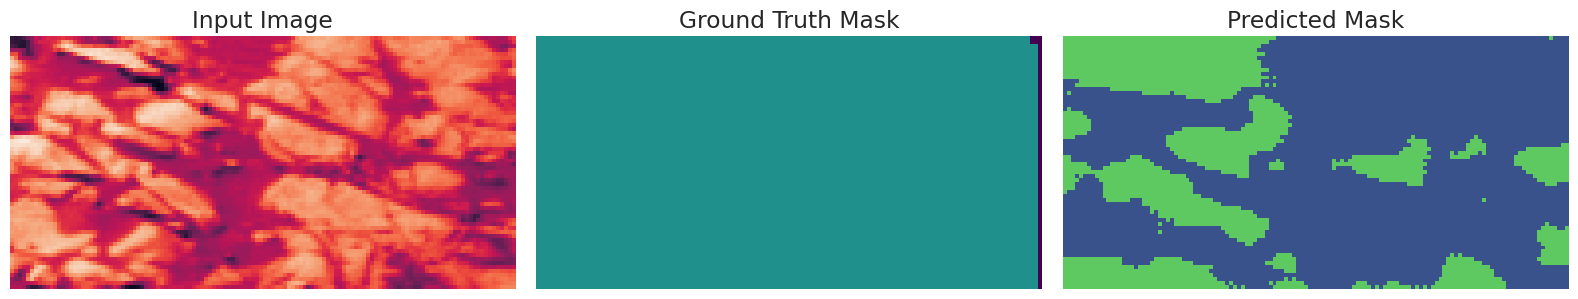


Epoch 1: val_mean_iou improved from -inf to 0.06659, saving model to Models/checkpoint.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.1584 - loss: 0.0062 - mean_iou: 0.0516 - val_accuracy: 0.1837 - val_loss: 0.0053 - val_mean_iou: 0.0666 - learning_rate: 1.0000e-04
Epoch 2/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1465 - loss: 0.0062 - mean_iou: 0.0520
Epoch 2: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.1461 - loss: 0.0062 - mean_iou: 0.0518 - val_accuracy: 0.1461 - val_loss: 0.0051 - val_mean_iou: 0.0395 - learning_rate: 1.0000e-04
Epoch 3/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.1388 - loss: 0.0060 - mean_iou: 0.0391
Epoch 3: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 455ms/step - accuracy: 0.1388 - loss: 0.0060 - mean_iou: 0.0392 - val_accuracy: 0.1554 - val_loss: 0.0049 - val_mean_iou: 0.0484 - learning_rate: 1.0000e-04
Epoch 4/1000
30/30 ━━━━━━━━━

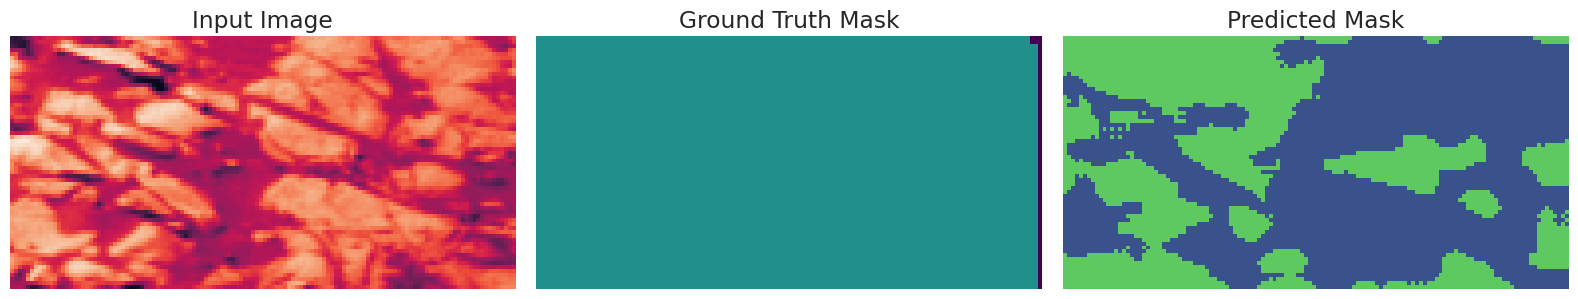


Epoch 6: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 460ms/step - accuracy: 0.1403 - loss: 0.0053 - mean_iou: 0.0417 - val_accuracy: 0.1421 - val_loss: 0.0047 - val_mean_iou: 0.0411 - learning_rate: 1.0000e-04
Epoch 7/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.1411 - loss: 0.0055 - mean_iou: 0.0455
Epoch 7: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 444ms/step - accuracy: 0.1408 - loss: 0.0055 - mean_iou: 0.0454 - val_accuracy: 0.1395 - val_loss: 0.0047 - val_mean_iou: 0.0390 - learning_rate: 1.0000e-04
Epoch 8/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.1500 - loss: 0.0057 - mean_iou: 0.0483
Epoch 8: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 444ms/step - accuracy: 0.1504 - loss: 0.0057 - mean_iou: 0.0486 - val_accuracy: 0.1747 - val_loss: 0.0052 - val_mean_iou: 0.0603 - learning_rate: 1.0000e-04
Epoch 9/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.

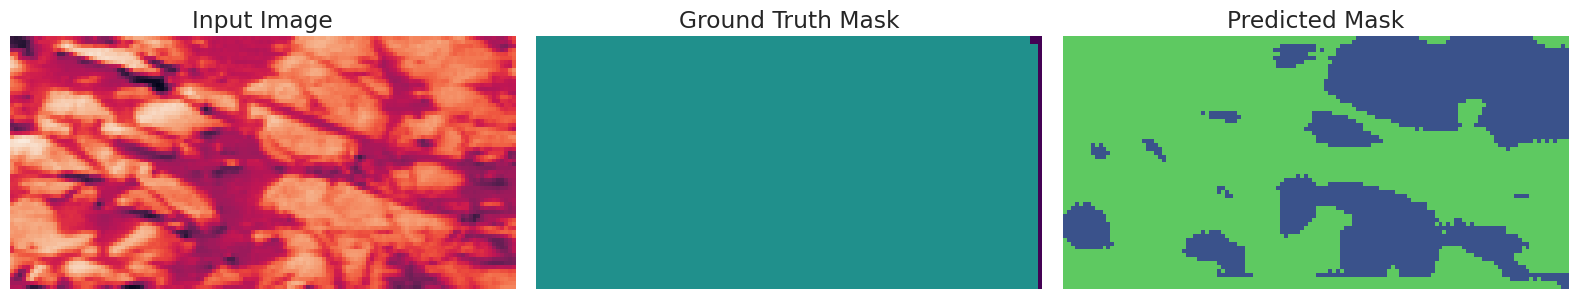


Epoch 11: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step - accuracy: 0.1327 - loss: 0.0053 - mean_iou: 0.0358 - val_accuracy: 0.1354 - val_loss: 0.0047 - val_mean_iou: 0.0384 - learning_rate: 1.0000e-05
Epoch 12/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.1369 - loss: 0.0052 - mean_iou: 0.0378
Epoch 12: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 456ms/step - accuracy: 0.1368 - loss: 0.0052 - mean_iou: 0.0378 - val_accuracy: 0.1353 - val_loss: 0.0046 - val_mean_iou: 0.0384 - learning_rate: 1.0000e-05
Epoch 13/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.1333 - loss: 0.0055 - mean_iou: 0.0370
Epoch 13: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 444ms/step - accuracy: 0.1332 - loss: 0.0055 - mean_iou: 0.0370 - val_accuracy: 0.1385 - val_loss: 0.0046 - val_mean_iou: 0.0393 - learning_rate: 1.0000e-05
Epoch 14/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accura

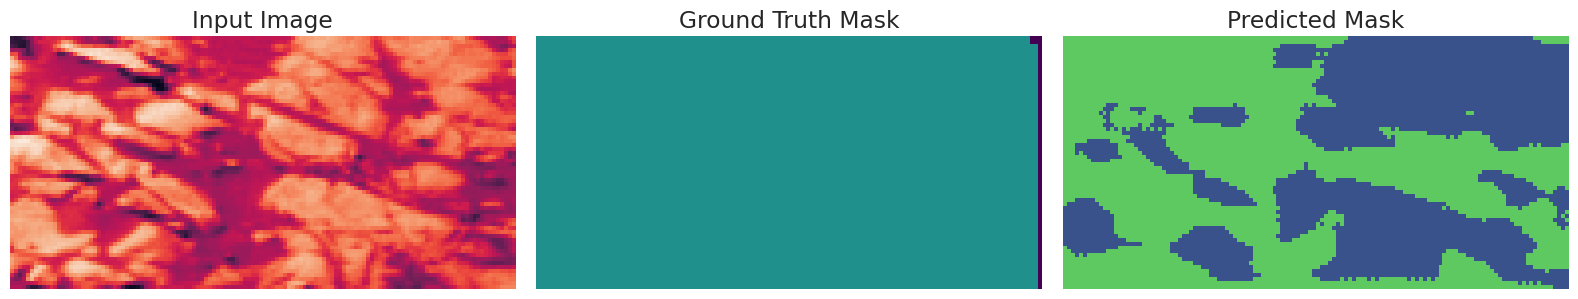


Epoch 16: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 460ms/step - accuracy: 0.1382 - loss: 0.0050 - mean_iou: 0.0423 - val_accuracy: 0.1371 - val_loss: 0.0045 - val_mean_iou: 0.0402 - learning_rate: 1.0000e-05
Epoch 17/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1331 - loss: 0.0049 - mean_iou: 0.0394
Epoch 17: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step - accuracy: 0.1330 - loss: 0.0049 - mean_iou: 0.0393 - val_accuracy: 0.1356 - val_loss: 0.0045 - val_mean_iou: 0.0383 - learning_rate: 1.0000e-05
Epoch 18/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.1374 - loss: 0.0050 - mean_iou: 0.0387
Epoch 18: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 448ms/step - accuracy: 0.1374 - loss: 0.0050 - mean_iou: 0.0388 - val_accuracy: 0.1403 - val_loss: 0.0045 - val_mean_iou: 0.0432 - learning_rate: 1.0000e-05
Epoch 19/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accura

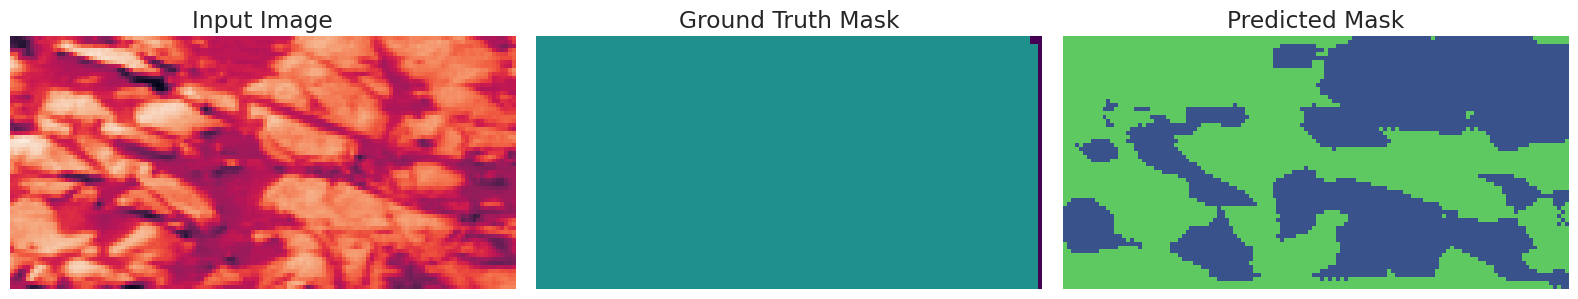


Epoch 21: val_mean_iou did not improve from 0.06659

Epoch 21: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 463ms/step - accuracy: 0.1385 - loss: 0.0050 - mean_iou: 0.0405 - val_accuracy: 0.1386 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-05
Epoch 22/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.1414 - loss: 0.0050 - mean_iou: 0.0432
Epoch 22: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 454ms/step - accuracy: 0.1413 - loss: 0.0050 - mean_iou: 0.0432 - val_accuracy: 0.1394 - val_loss: 0.0045 - val_mean_iou: 0.0424 - learning_rate: 1.0000e-06
Epoch 23/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1392 - loss: 0.0049 - mean_iou: 0.0427
Epoch 23: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 454ms/step - accuracy: 0.1390 - loss: 0.0049 - mean_iou: 0.0427 - val_accuracy: 0.1392 - val_loss: 0.0045 - val_mean_iou: 0.0420 - learning_ra

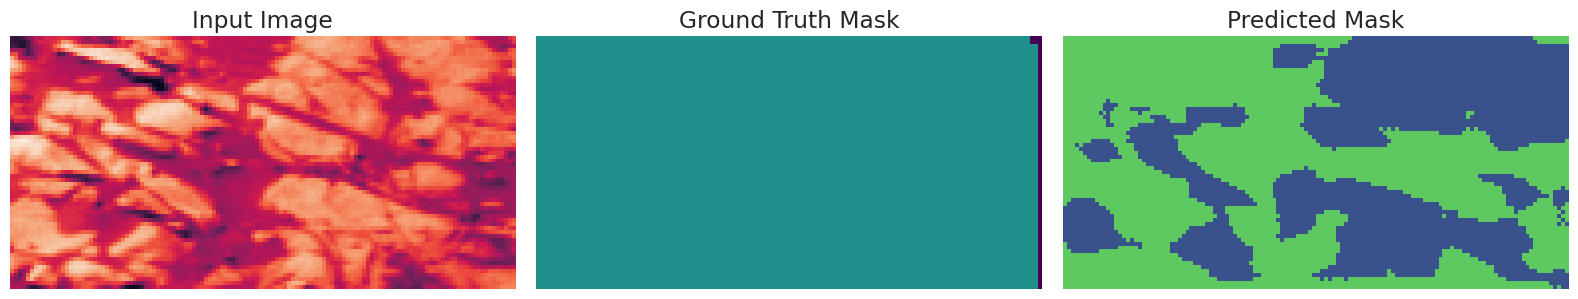


Epoch 26: val_mean_iou did not improve from 0.06659

Epoch 26: ReduceLROnPlateau reducing learning rate to 9.999999974752428e-08.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 465ms/step - accuracy: 0.1423 - loss: 0.0059 - mean_iou: 0.0436 - val_accuracy: 0.1399 - val_loss: 0.0045 - val_mean_iou: 0.0428 - learning_rate: 1.0000e-06
Epoch 27/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1379 - loss: 0.0049 - mean_iou: 0.0409
Epoch 27: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 446ms/step - accuracy: 0.1378 - loss: 0.0049 - mean_iou: 0.0410 - val_accuracy: 0.1399 - val_loss: 0.0045 - val_mean_iou: 0.0429 - learning_rate: 1.0000e-07
Epoch 28/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.1379 - loss: 0.0048 - mean_iou: 0.0418
Epoch 28: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 444ms/step - accuracy: 0.1379 - loss: 0.0048 - mean_iou: 0.0418 - val_accuracy: 0.1399 - val_loss: 0.0045 - val_mean_iou: 0.0428 - learning_ra

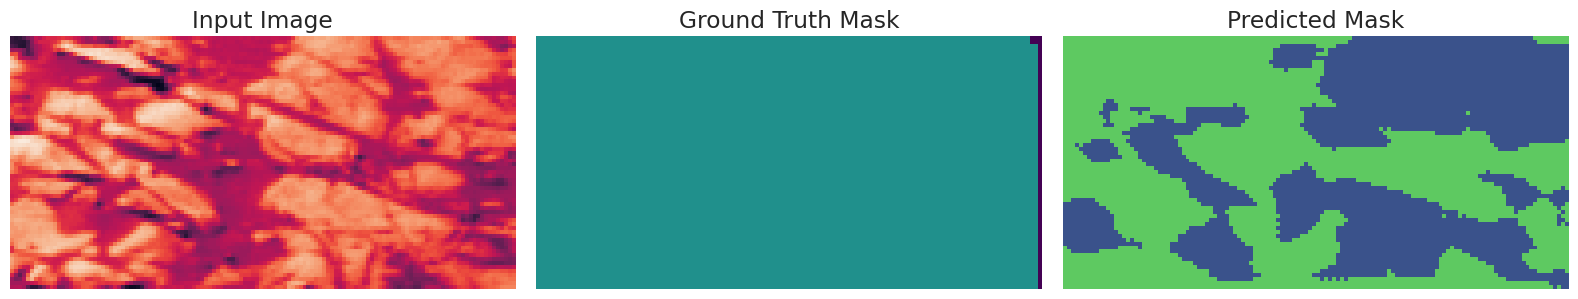


Epoch 31: val_mean_iou did not improve from 0.06659

Epoch 31: ReduceLROnPlateau reducing learning rate to 1.0000000116860975e-08.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.1375 - loss: 0.0047 - mean_iou: 0.0417 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-07
Epoch 32/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.1387 - loss: 0.0050 - mean_iou: 0.0414
Epoch 32: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 444ms/step - accuracy: 0.1386 - loss: 0.0050 - mean_iou: 0.0414 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-08
Epoch 33/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.1409 - loss: 0.0048 - mean_iou: 0.0424
Epoch 33: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 448ms/step - accuracy: 0.1408 - loss: 0.0048 - mean_iou: 0.0425 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_r

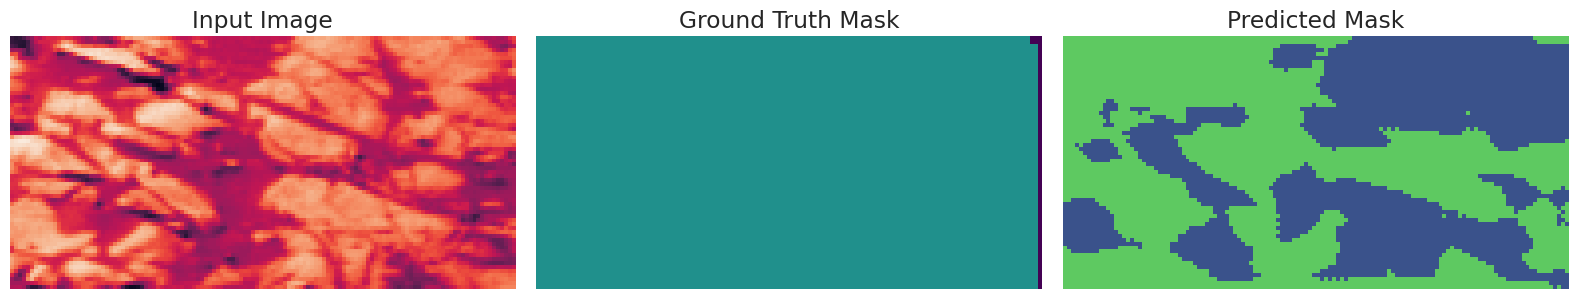


Epoch 36: val_mean_iou did not improve from 0.06659

Epoch 36: ReduceLROnPlateau reducing learning rate to 9.999999939225292e-10.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 464ms/step - accuracy: 0.1381 - loss: 0.0048 - mean_iou: 0.0419 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-08
Epoch 37/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.1422 - loss: 0.0050 - mean_iou: 0.0434
Epoch 37: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.1420 - loss: 0.0050 - mean_iou: 0.0434 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-09
Epoch 38/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.1378 - loss: 0.0050 - mean_iou: 0.0418
Epoch 38: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.1377 - loss: 0.0050 - mean_iou: 0.0419 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

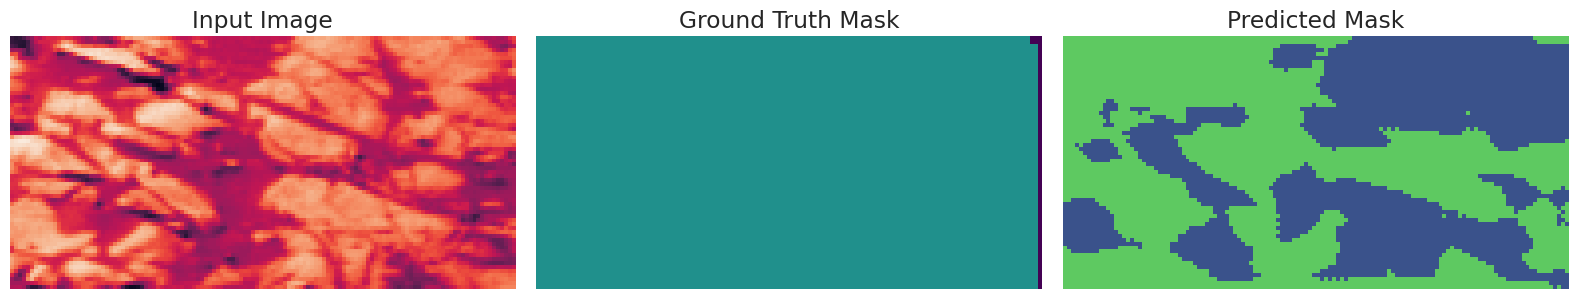


Epoch 41: val_mean_iou did not improve from 0.06659

Epoch 41: ReduceLROnPlateau reducing learning rate to 9.999999717180686e-11.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 460ms/step - accuracy: 0.1413 - loss: 0.0050 - mean_iou: 0.0432 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-09
Epoch 42/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1377 - loss: 0.0048 - mean_iou: 0.0412
Epoch 42: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 434ms/step - accuracy: 0.1376 - loss: 0.0048 - mean_iou: 0.0412 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-10
Epoch 43/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1380 - loss: 0.0050 - mean_iou: 0.0420
Epoch 43: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.1379 - loss: 0.0050 - mean_iou: 0.0420 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

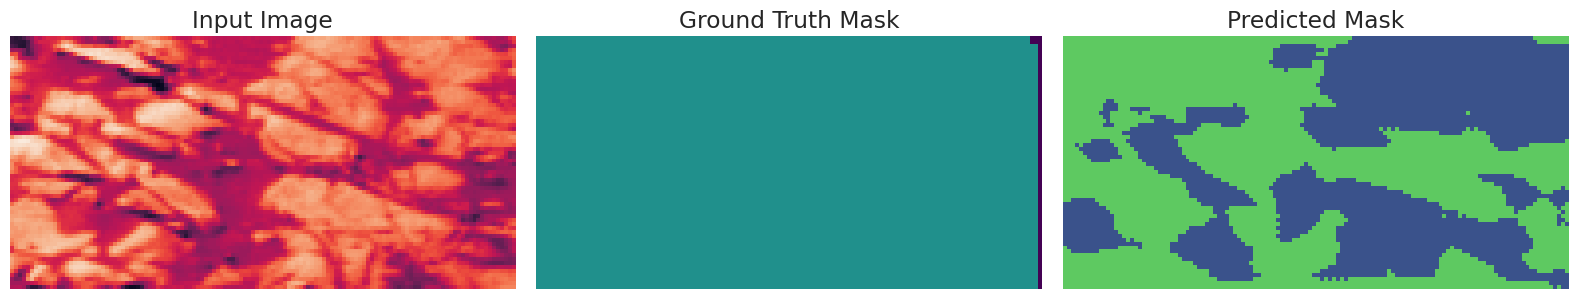


Epoch 46: val_mean_iou did not improve from 0.06659

Epoch 46: ReduceLROnPlateau reducing learning rate to 9.99999943962493e-12.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.1373 - loss: 0.0049 - mean_iou: 0.0405 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-10
Epoch 47/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1423 - loss: 0.0052 - mean_iou: 0.0430
Epoch 47: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 446ms/step - accuracy: 0.1422 - loss: 0.0052 - mean_iou: 0.0430 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-11
Epoch 48/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.1392 - loss: 0.0049 - mean_iou: 0.0419
Epoch 48: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 455ms/step - accuracy: 0.1391 - loss: 0.0049 - mean_iou: 0.0419 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rat

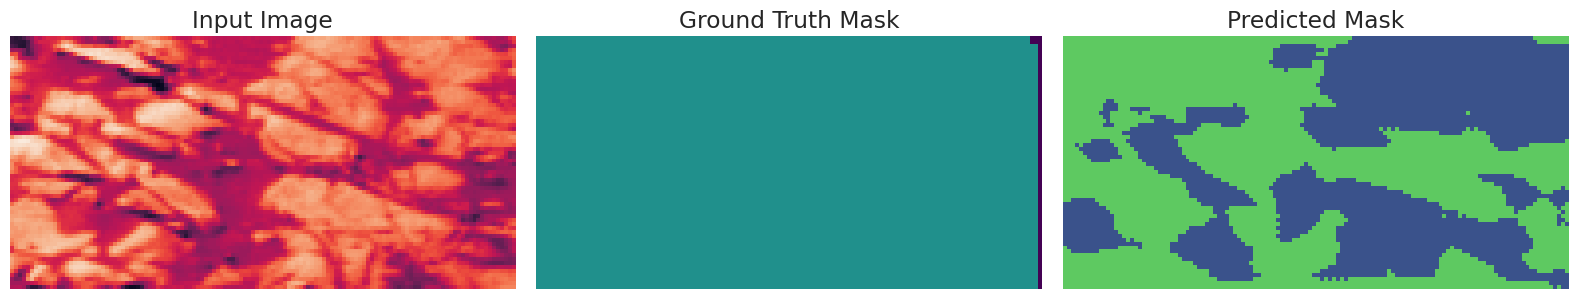


Epoch 51: val_mean_iou did not improve from 0.06659

Epoch 51: ReduceLROnPlateau reducing learning rate to 9.999999092680235e-13.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 468ms/step - accuracy: 0.1371 - loss: 0.0050 - mean_iou: 0.0428 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-11
Epoch 52/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1399 - loss: 0.0048 - mean_iou: 0.0420
Epoch 52: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step - accuracy: 0.1398 - loss: 0.0048 - mean_iou: 0.0420 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-12
Epoch 53/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1378 - loss: 0.0051 - mean_iou: 0.0407
Epoch 53: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 442ms/step - accuracy: 0.1377 - loss: 0.0051 - mean_iou: 0.0407 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

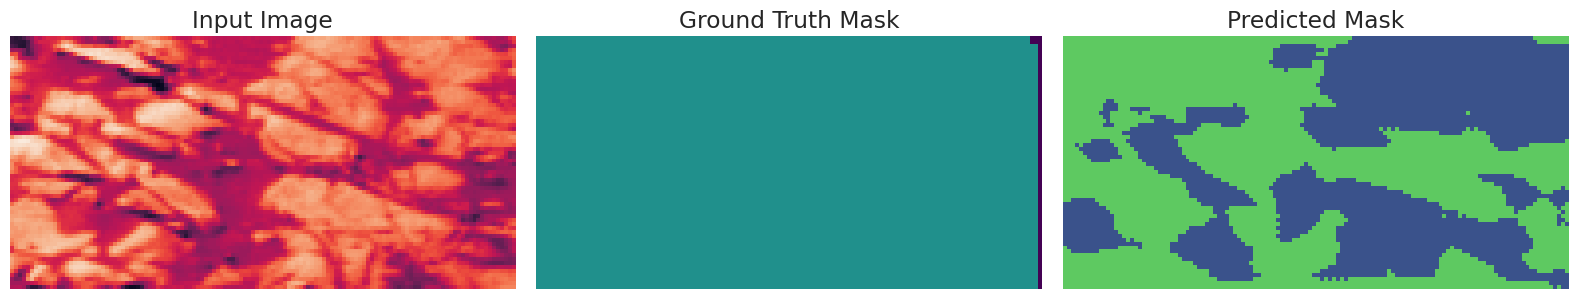


Epoch 56: val_mean_iou did not improve from 0.06659

Epoch 56: ReduceLROnPlateau reducing learning rate to 9.9999988758398e-14.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 476ms/step - accuracy: 0.1390 - loss: 0.0051 - mean_iou: 0.0423 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-12
Epoch 57/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.1371 - loss: 0.0049 - mean_iou: 0.0416
Epoch 57: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 451ms/step - accuracy: 0.1370 - loss: 0.0049 - mean_iou: 0.0416 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-13
Epoch 58/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.1425 - loss: 0.0051 - mean_iou: 0.0439
Epoch 58: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.1423 - loss: 0.0051 - mean_iou: 0.0439 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate

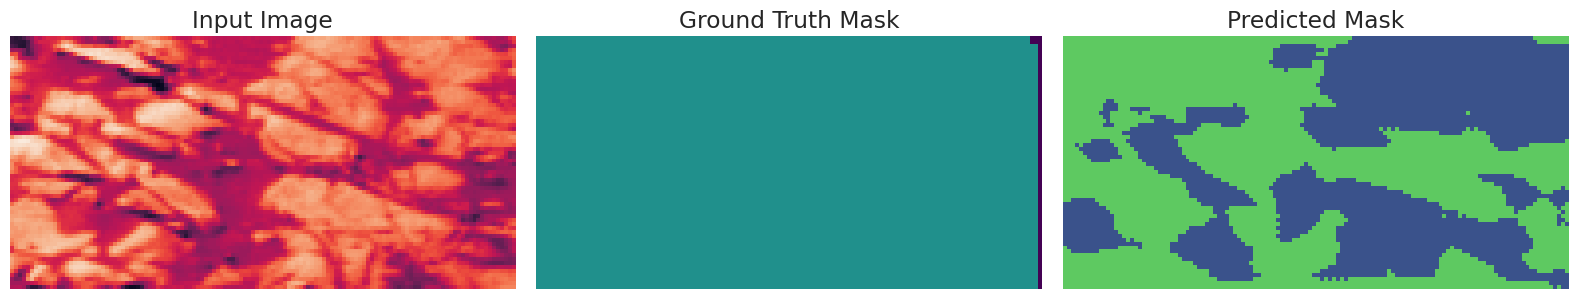


Epoch 61: val_mean_iou did not improve from 0.06659

Epoch 61: ReduceLROnPlateau reducing learning rate to 9.999999146890344e-15.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 467ms/step - accuracy: 0.1398 - loss: 0.0048 - mean_iou: 0.0436 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-13
Epoch 62/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.1394 - loss: 0.0049 - mean_iou: 0.0420
Epoch 62: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 447ms/step - accuracy: 0.1392 - loss: 0.0049 - mean_iou: 0.0420 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-14
Epoch 63/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.1393 - loss: 0.0049 - mean_iou: 0.0432
Epoch 63: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.1391 - loss: 0.0049 - mean_iou: 0.0432 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

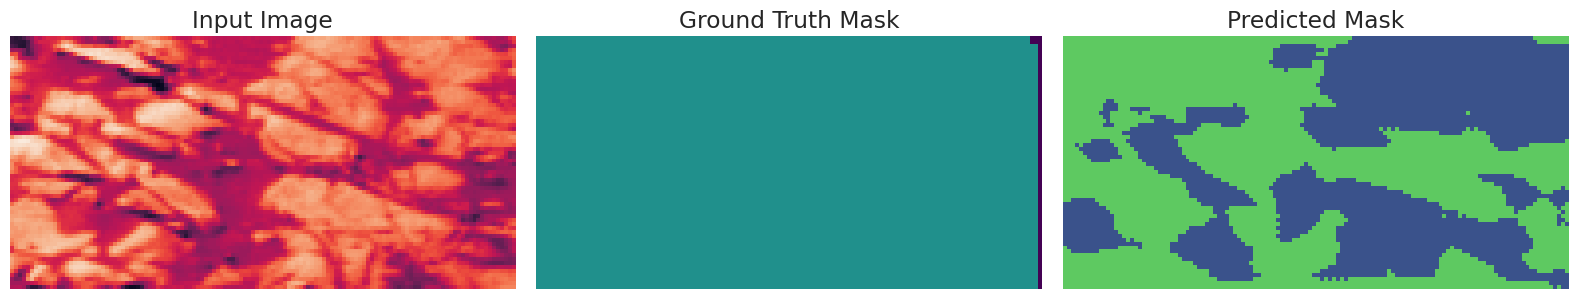


Epoch 66: val_mean_iou did not improve from 0.06659

Epoch 66: ReduceLROnPlateau reducing learning rate to 9.999998977483753e-16.
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 465ms/step - accuracy: 0.1385 - loss: 0.0047 - mean_iou: 0.0427 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-14
Epoch 67/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.1416 - loss: 0.0049 - mean_iou: 0.0424
Epoch 67: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 443ms/step - accuracy: 0.1415 - loss: 0.0049 - mean_iou: 0.0424 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-15
Epoch 68/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.1396 - loss: 0.0049 - mean_iou: 0.0427
Epoch 68: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 440ms/step - accuracy: 0.1395 - loss: 0.0049 - mean_iou: 0.0427 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

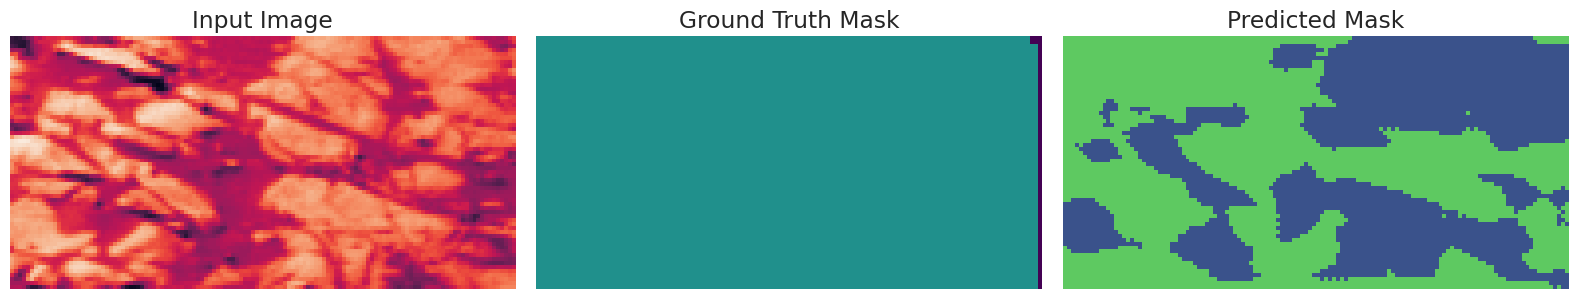


Epoch 71: val_mean_iou did not improve from 0.06659

Epoch 71: ReduceLROnPlateau reducing learning rate to 9.999998977483754e-17.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 461ms/step - accuracy: 0.1401 - loss: 0.0052 - mean_iou: 0.0428 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-15
Epoch 72/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.1398 - loss: 0.0053 - mean_iou: 0.0422
Epoch 72: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 442ms/step - accuracy: 0.1396 - loss: 0.0053 - mean_iou: 0.0422 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-16
Epoch 73/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.1388 - loss: 0.0048 - mean_iou: 0.0421
Epoch 73: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 436ms/step - accuracy: 0.1387 - loss: 0.0048 - mean_iou: 0.0421 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

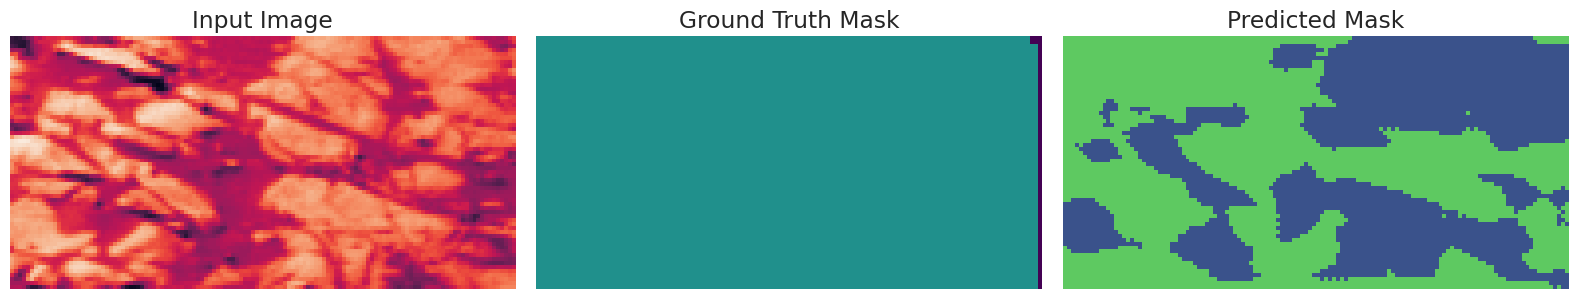


Epoch 76: val_mean_iou did not improve from 0.06659

Epoch 76: ReduceLROnPlateau reducing learning rate to 9.999998845134856e-18.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.1360 - loss: 0.0049 - mean_iou: 0.0413 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-16
Epoch 77/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1404 - loss: 0.0050 - mean_iou: 0.0430
Epoch 77: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 435ms/step - accuracy: 0.1403 - loss: 0.0050 - mean_iou: 0.0430 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-17
Epoch 78/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.1381 - loss: 0.0059 - mean_iou: 0.0416
Epoch 78: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 438ms/step - accuracy: 0.1380 - loss: 0.0058 - mean_iou: 0.0416 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

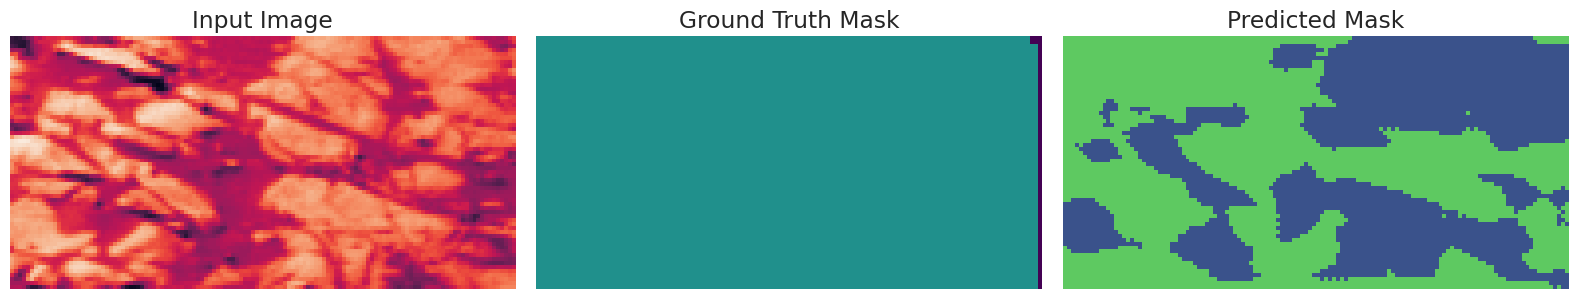


Epoch 81: val_mean_iou did not improve from 0.06659

Epoch 81: ReduceLROnPlateau reducing learning rate to 9.999999010570977e-19.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.1408 - loss: 0.0048 - mean_iou: 0.0419 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-17
Epoch 82/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1401 - loss: 0.0047 - mean_iou: 0.0432
Epoch 82: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 435ms/step - accuracy: 0.1399 - loss: 0.0047 - mean_iou: 0.0432 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_rate: 1.0000e-18
Epoch 83/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.1406 - loss: 0.0046 - mean_iou: 0.0438
Epoch 83: val_mean_iou did not improve from 0.06659
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 438ms/step - accuracy: 0.1404 - loss: 0.0046 - mean_iou: 0.0437 - val_accuracy: 0.1396 - val_loss: 0.0045 - val_mean_iou: 0.0425 - learning_ra

In [ ]:
model = tfk.models.load_model(
    'Models/UNet_14.32.keras',
    compile=False,  # Non compila subito il modello
    custom_objects={
        'weighted_sparse_categorical_crossentropy': weighted_sparse_categorical_crossentropy,
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=weighted_sparse_categorical_crossentropy,  # Custom loss
    metrics=["accuracy", MeanIntersectionOverUnion(num_classes=NUM_CLASSES, labels_to_exclude=[0])]
)


history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, viz_callback, checkpoint, reduceLROnPlateau],
    verbose=1
).history

# Calculate and print the final validation accuracy
final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'UNet_'+str(final_val_meanIoU)+'.keras'
model.save('Models/' + model_filename)

# Delete the model to free up resources
del model

##Visualize model results

In [ ]:
# Plot and display training and validation loss
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation accuracy
plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation mean IoU
plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##Load the model

In [ ]:
# Load UNet model without compiling
model = tfk.models.load_model(
    'Models/UNet_14.32.keras',
    compile=False,  # Non compila subito il modello
    custom_objects={
        'weighted_sparse_categorical_crossentropy': weighted_sparse_categorical_crossentropy,
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)

# Compile the model with specified loss, optimizer, and metrics
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tfk.optimizers.AdamW(LEARNING_RATE),
    metrics=["accuracy", MeanIntersectionOverUnion(num_classes=NUM_CLASSES, labels_to_exclude=[0])]
)

# Print a detailed summary of the model with expanded nested layers and trainable parameters.
model.summary(expand_nested=True, show_trainable=True)

# Generate and display a graphical representation of the model architecture.
tf.keras.utils.plot_model(model, show_trainable=True, expand_nested=True, dpi=70)

#Attention U-Net

##Loss Function

In [ ]:
def calculate_class_weights(pixel_counts_dict, normalize=True):
    """
    Calculate a weights tensor based on the number of pixels per class.
    """
    class_labels = list(pixel_counts_dict.keys())
    pixel_counts = np.array(list(pixel_counts_dict.values()), dtype=np.float32)

    with np.errstate(divide='ignore', invalid='ignore'):
        weights = np.where(pixel_counts > 0, 1.0 / pixel_counts, 0.0)

    if normalize:
        weights = weights / np.sum(weights)

    weights_tensor = tf.constant(weights, dtype=tf.float32)
    return weights_tensor

def focal_loss(y_true, y_pred, gamma=2., alpha=0.25):
    """
    Focal Loss for multi-class classification.
    """
    epsilon = tf.keras.backend.epsilon()
    y_true = tf.cast(y_true, tf.float32)

    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)
    loss = alpha * tf.pow(1 - y_pred, gamma) * cross_entropy
    return tf.reduce_mean(loss)

def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss function.
    """
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice_score = 1 - (2. * intersection + smooth) / (union + smooth)
    return dice_score

def weighted_sparse_categorical_crossentropy(y_true, y_pred, normalize=True):
    """
    Weighted Sparse Categorical Cross-Entropy Loss Function with class weights.
    """
    pixel_counts = {
        0 :  0.0,
        1 :  7131118.0,
        2 :  4863930.0,
        3 :  3933183.0,
        4 :  26963.0,
    }

    weights_tensor = calculate_class_weights(pixel_counts, normalize)

    # Flatten tensors
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

    # Mask to ignore background (class 0)
    mask = tf.cast(y_true > 0, dtype=tf.float32)

    # Shift y_true to exclude background class (class 0)
    y_true_shifted = tf.cast(y_true - 1, tf.int32)  # Cast to int32

    # One-hot encoding of y_true
    y_true_one_hot = tf.one_hot(y_true_shifted, depth=tf.shape(y_pred)[-1])

    # Calculate categorical cross-entropy
    loss = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)

    # Gather the weights for each class using the indices in y_true (casted to int32)
    weights = tf.gather(weights_tensor, y_true_shifted)  # Use y_true_shifted instead of y_true
    weights = weights * mask  # Apply mask to ignore background class

    # Weighted loss
    weighted_loss = loss * weights

    # Normalize by the total number of valid pixels (ignoring background)
    return tf.reduce_sum(weighted_loss) / tf.reduce_sum(mask)

def combined_loss(y_true, y_pred, gamma=2., alpha=0.25, normalize=True, dice_weight=1.0, focal_weight=1.0, ce_weight=1.0):
    """
    Combined loss function with Dice Loss, Focal Loss, and Weighted Categorical Cross-Entropy.
    """

    # Calculate individual loss components
    ce_loss = weighted_sparse_categorical_crossentropy(y_true, y_pred, normalize)
    f_loss = focal_loss(y_true, y_pred, gamma, alpha)
    d_loss = dice_loss(y_true, y_pred)

    # Combine the losses with respective weights
    total_loss = ce_weight * ce_loss + focal_weight * f_loss + dice_weight * d_loss
    return total_loss

##Building model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout, Activation, Multiply, Add
from tensorflow.keras.models import Model

# Convolutional Block
def conv_block(inputs, num_filters, dropout_rate=0.1):
    """
    A convolutional block: Conv2D -> ReLU -> Conv2D -> ReLU -> Dropout.
    Args:
        inputs: Input tensor.
        num_filters: Number of filters for the convolution layers.
        dropout_rate: Dropout rate to regularize the model.
    Returns:
        Tensor after applying convolutional layers and dropout.
    """
    x = Conv2D(num_filters, kernel_size=3, padding="same", activation="relu")(inputs)
    x = Conv2D(num_filters, kernel_size=3, padding="same", activation="relu")(x)
    x = Dropout(dropout_rate)(x)
    return x

# Attention Block
def attention_block(skip_features, gating_signal, num_filters):
    """
    Attention block to enhance relevant features in the skip connection.
    Args:
        skip_features: Features from the encoder (skip connection).
        gating_signal: Features from the decoder (gating signal).
        num_filters: Number of filters for intermediate layers.
    Returns:
        Tensor after applying attention mechanism to the skip connection.
    """
    theta = Conv2D(num_filters, kernel_size=1, strides=1, padding='same')(skip_features)  # Reduce dimensions
    phi = Conv2D(num_filters, kernel_size=1, strides=1, padding='same')(gating_signal)    # Reduce dimensions
    f = Add()([theta, phi])                                                              # Element-wise addition
    f = Activation('relu')(f)                                                           # Non-linear activation
    psi = Conv2D(1, kernel_size=1, strides=1, padding='same', activation='sigmoid')(f)   # Sigmoid activation
    attention_weights = Multiply()([skip_features, psi])                                 # Element-wise multiplication
    return attention_weights

# Encoder Block
def encoder_block(inputs, num_filters, dropout_rate=0.1):
    """
    Encoder block with convolutional feature extraction and downsampling.
    Args:
        inputs: Input tensor.
        num_filters: Number of filters for convolution layers.
        dropout_rate: Dropout rate to regularize the model.
    Returns:
        skip_features: Features for skip connections.
        pooled_features: Downsampled features for the next encoder block.
    """
    x = conv_block(inputs, num_filters, dropout_rate)
    p = MaxPooling2D(pool_size=(2, 2))(x)  # Downsample
    return x, p

# Decoder Block
def decoder_block(inputs, skip_features, num_filters):
    """
    Decoder block with upsampling and skip connections enhanced by attention.
    Args:
        inputs: Input tensor from the previous layer.
        skip_features: Features from the encoder for skip connections.
        num_filters: Number of filters for convolution layers.
    Returns:
        Tensor after applying upsampling and merging with skip features.
    """
    x = Conv2DTranspose(num_filters, kernel_size=2, strides=2, padding="same")(inputs)   # Upsample
    attn = attention_block(skip_features, x, num_filters)                               # Attention mechanism
    x = concatenate([x, attn])                                                         # Concatenate skip features
    x = conv_block(x, num_filters)                                                     # Apply convolutions
    return x

# U-Net with Attention
def build_attention_unet(input_shape=(64, 128, 1), num_classes=5):
    """
    Constructs an Attention U-Net model for semantic segmentation.
    Args:
        input_shape: Shape of the input image (height, width, channels).
        num_classes: Number of output classes.
    Returns:
        Compiled Attention U-Net model.
    """
    # Input layer
    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)   # Stage 1
    s2, p2 = encoder_block(p1, 128)      # Stage 2
    s3, p3 = encoder_block(p2, 256)      # Stage 3
    s4, p4 = encoder_block(p3, 512)      # Stage 4

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)      # Stage 4
    d2 = decoder_block(d1, s3, 256)      # Stage 3
    d3 = decoder_block(d2, s2, 128)      # Stage 2
    d4 = decoder_block(d3, s1, 64)       # Stage 1

    # Output layer: 1x1 convolution to produce class probabilities
    outputs = Conv2D(num_classes, kernel_size=1, activation="softmax")(d4)

    # Create the model
    model = Model(inputs, outputs, name="Attention-U-Net")
    return model

# Build the model
input_shape = (64, 128, 1)  # Grayscale images
num_classes = 5             # Terrain classes
att_model = build_attention_unet(input_shape=input_shape, num_classes=num_classes)

'''
# Compile the model
att_model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",  # Use a weighted loss if necessary
    metrics=["accuracy"]  # Add MeanIoU metric for evaluation
)
'''
# Summary of the model
#model.summary()

## Setup Callbacks

In [ ]:
#Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    mode='min',
    patience=PATIENCE,
    restore_best_weights=True
)

random_number = random.randint(0, X_val.shape[0])

viz_callback = VizCallback(X_val[random_number], Y_val[random_number])

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='Models/checkpoint.keras',
    monitor='val_mean_iou',
    mode='max',
    save_best_only=True,
    verbose = True
)

reduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    verbose=1
)

##Training

Epoch 1/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4312 - loss: 0.5452 - mean_iou: 0.1690   

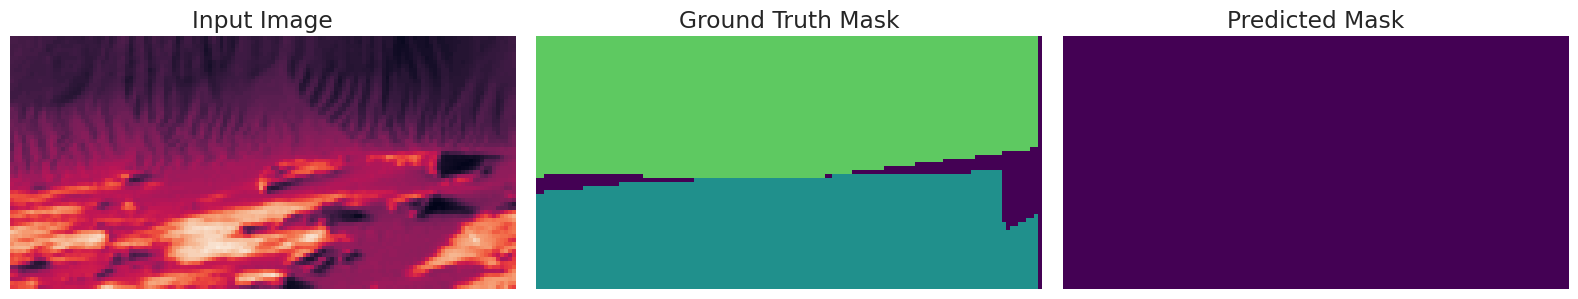


Epoch 1: val_mean_iou improved from -inf to 0.01496, saving model to Models/checkpoint.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.4273 - loss: 0.5380 - mean_iou: 0.1660 - val_accuracy: 0.2517 - val_loss: 0.2091 - val_mean_iou: 0.0150 - learning_rate: 1.0000e-04
Epoch 2/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2687 - loss: 0.2077 - mean_iou: 0.0216
Epoch 2: val_mean_iou did not improve from 0.01496
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - accuracy: 0.2682 - loss: 0.2077 - mean_iou: 0.0215 - val_accuracy: 0.2493 - val_loss: 0.2057 - val_mean_iou: 0.0047 - learning_rate: 1.0000e-04
Epoch 3/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.2618 - loss: 0.2050 - mean_iou: 0.0106
Epoch 3: val_mean_iou improved from 0.01496 to 0.04789, saving model to Models/checkpoint.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 563ms/step - accuracy: 0.2614 - loss: 0.2049 - mean_iou: 0.0109 - val_accuracy: 0.2722 - val_loss: 0.2050 - val_mean_iou: 0.0479 - learning_

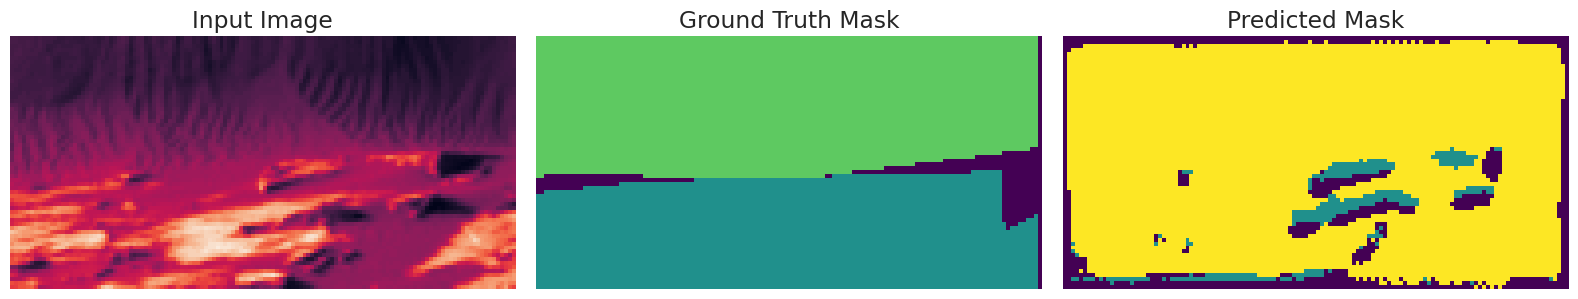


Epoch 6: val_mean_iou improved from 0.16895 to 0.18678, saving model to Models/checkpoint.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 582ms/step - accuracy: 0.2560 - loss: 0.2052 - mean_iou: 0.1239 - val_accuracy: 0.3562 - val_loss: 0.2047 - val_mean_iou: 0.1868 - learning_rate: 1.0000e-04
Epoch 7/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2605 - loss: 0.2071 - mean_iou: 0.1296
Epoch 7: val_mean_iou improved from 0.18678 to 0.19013, saving model to Models/checkpoint.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 573ms/step - accuracy: 0.2606 - loss: 0.2070 - mean_iou: 0.1296 - val_accuracy: 0.3595 - val_loss: 0.2046 - val_mean_iou: 0.1901 - learning_rate: 1.0000e-04
Epoch 8/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.2564 - loss: 0.2046 - mean_iou: 0.1281
Epoch 8: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 491ms/step - accuracy: 0.2565 - loss: 0.2045 - mean_iou: 0.1281 - val_accuracy: 0.3506 - val_loss: 0.2046 - val_mean_iou: 0.1869 - lear

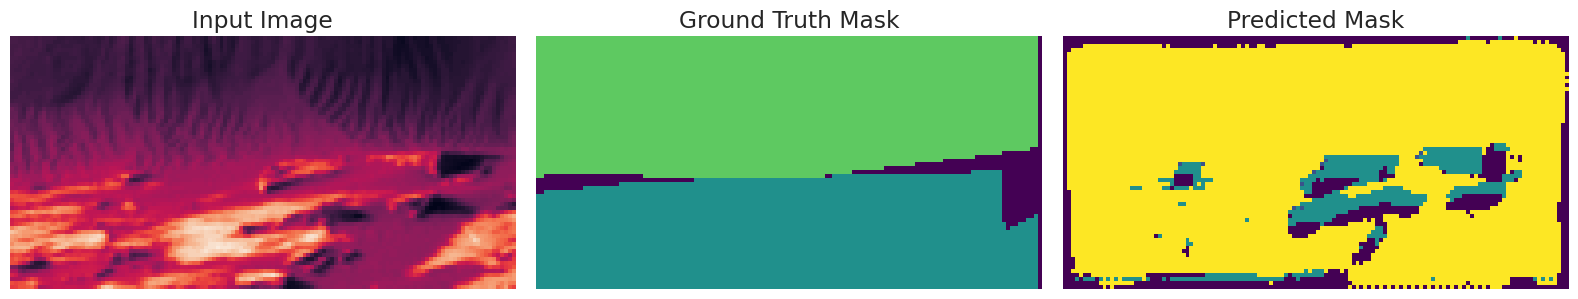


Epoch 11: val_mean_iou did not improve from 0.19013

Epoch 11: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 497ms/step - accuracy: 0.2403 - loss: 0.2028 - mean_iou: 0.1162 - val_accuracy: 0.2587 - val_loss: 0.2046 - val_mean_iou: 0.1206 - learning_rate: 1.0000e-04
Epoch 12/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2393 - loss: 0.2037 - mean_iou: 0.1140
Epoch 12: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 486ms/step - accuracy: 0.2395 - loss: 0.2037 - mean_iou: 0.1140 - val_accuracy: 0.2577 - val_loss: 0.2046 - val_mean_iou: 0.1184 - learning_rate: 1.0000e-05
Epoch 13/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2423 - loss: 0.2033 - mean_iou: 0.1165
Epoch 13: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - accuracy: 0.2425 - loss: 0.2032 - mean_iou: 0.1165 - val_accuracy: 0.2517 - val_loss: 0.2046 - val_mean_iou: 0.1132 - learning_ra

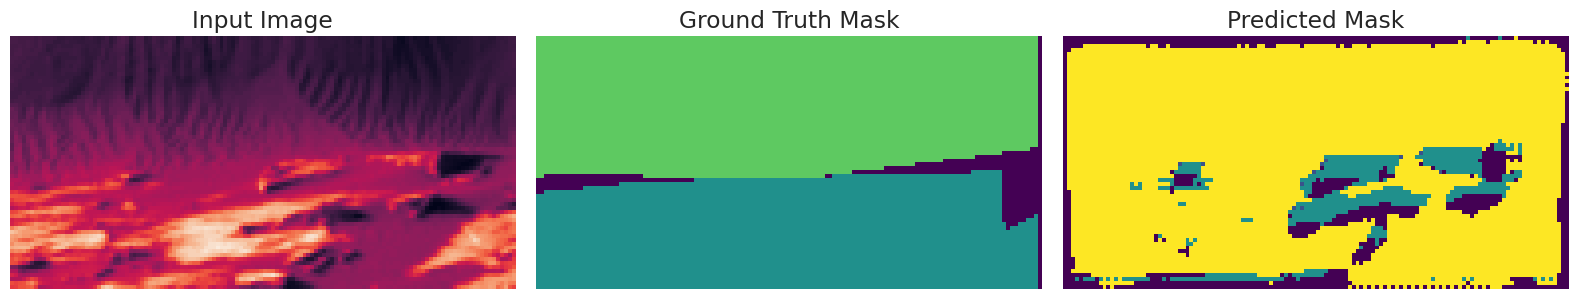


Epoch 16: val_mean_iou did not improve from 0.19013

Epoch 16: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 507ms/step - accuracy: 0.2404 - loss: 0.2038 - mean_iou: 0.1148 - val_accuracy: 0.2476 - val_loss: 0.2046 - val_mean_iou: 0.1083 - learning_rate: 1.0000e-05
Epoch 17/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2383 - loss: 0.2037 - mean_iou: 0.1128
Epoch 17: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step - accuracy: 0.2385 - loss: 0.2037 - mean_iou: 0.1129 - val_accuracy: 0.2475 - val_loss: 0.2046 - val_mean_iou: 0.1082 - learning_rate: 1.0000e-06
Epoch 18/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.2410 - loss: 0.2046 - mean_iou: 0.1151
Epoch 18: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 477ms/step - accuracy: 0.2412 - loss: 0.2045 - mean_iou: 0.1151 - val_accuracy: 0.2472 - val_loss: 0.2046 - val_mean_iou: 0.1080 - learning_ra

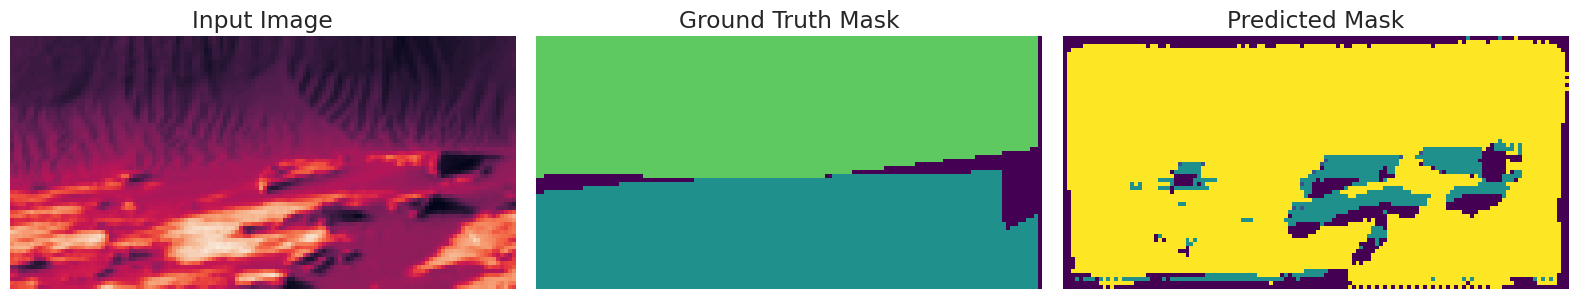


Epoch 21: val_mean_iou did not improve from 0.19013

Epoch 21: ReduceLROnPlateau reducing learning rate to 9.999999974752428e-08.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 499ms/step - accuracy: 0.2396 - loss: 0.2034 - mean_iou: 0.1139 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-06
Epoch 22/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2392 - loss: 0.2047 - mean_iou: 0.1132
Epoch 22: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 483ms/step - accuracy: 0.2394 - loss: 0.2047 - mean_iou: 0.1132 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-07
Epoch 23/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2391 - loss: 0.2060 - mean_iou: 0.1130
Epoch 23: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - accuracy: 0.2393 - loss: 0.2059 - mean_iou: 0.1130 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

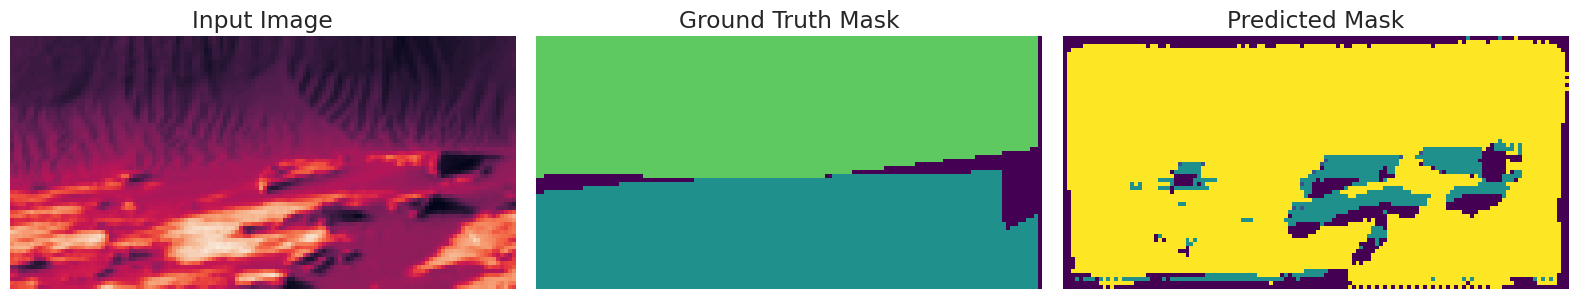


Epoch 26: val_mean_iou did not improve from 0.19013

Epoch 26: ReduceLROnPlateau reducing learning rate to 1.0000000116860975e-08.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 515ms/step - accuracy: 0.2410 - loss: 0.2033 - mean_iou: 0.1140 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-07
Epoch 27/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.2392 - loss: 0.2038 - mean_iou: 0.1129
Epoch 27: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 478ms/step - accuracy: 0.2393 - loss: 0.2037 - mean_iou: 0.1129 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-08
Epoch 28/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2406 - loss: 0.2046 - mean_iou: 0.1136
Epoch 28: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 480ms/step - accuracy: 0.2408 - loss: 0.2045 - mean_iou: 0.1136 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_r

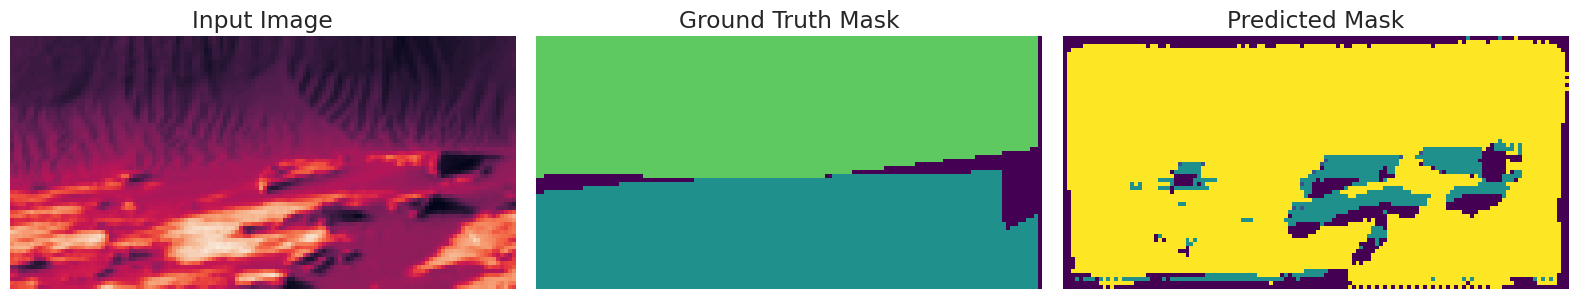


Epoch 31: val_mean_iou did not improve from 0.19013

Epoch 31: ReduceLROnPlateau reducing learning rate to 9.999999939225292e-10.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 499ms/step - accuracy: 0.2412 - loss: 0.2032 - mean_iou: 0.1134 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-08
Epoch 32/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2404 - loss: 0.2031 - mean_iou: 0.1135
Epoch 32: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 488ms/step - accuracy: 0.2406 - loss: 0.2031 - mean_iou: 0.1135 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-09
Epoch 33/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2404 - loss: 0.2036 - mean_iou: 0.1132
Epoch 33: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 482ms/step - accuracy: 0.2405 - loss: 0.2036 - mean_iou: 0.1133 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

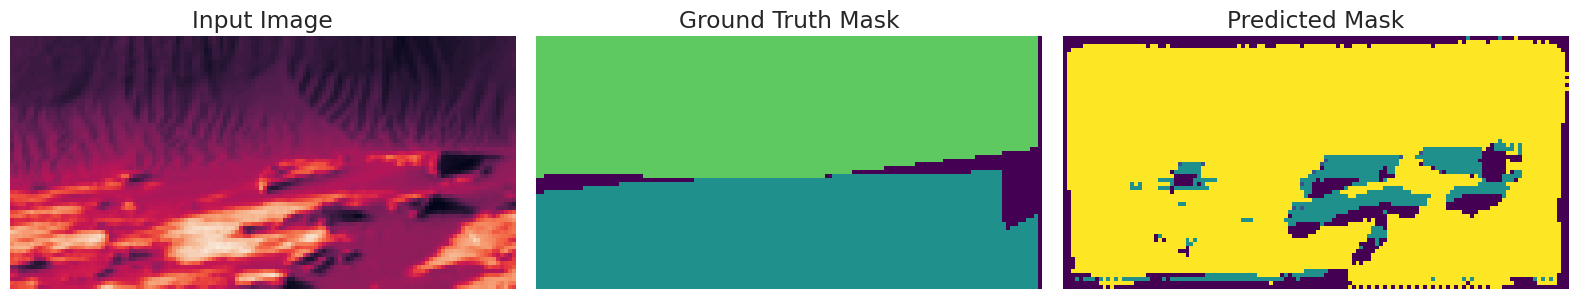


Epoch 36: val_mean_iou did not improve from 0.19013

Epoch 36: ReduceLROnPlateau reducing learning rate to 9.999999717180686e-11.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 503ms/step - accuracy: 0.2405 - loss: 0.2030 - mean_iou: 0.1136 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-09
Epoch 37/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2412 - loss: 0.2041 - mean_iou: 0.1131
Epoch 37: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step - accuracy: 0.2413 - loss: 0.2041 - mean_iou: 0.1131 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-10
Epoch 38/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2410 - loss: 0.2039 - mean_iou: 0.1139
Epoch 38: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - accuracy: 0.2412 - loss: 0.2038 - mean_iou: 0.1140 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

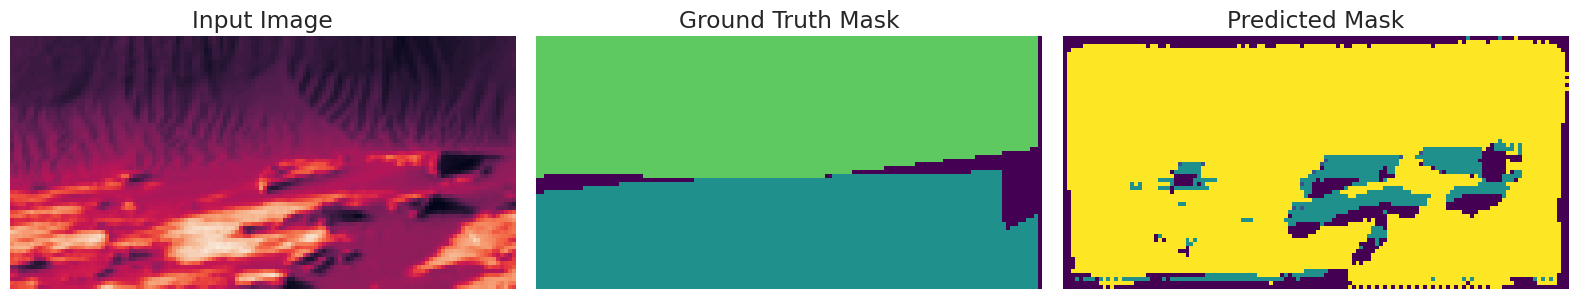


Epoch 41: val_mean_iou did not improve from 0.19013

Epoch 41: ReduceLROnPlateau reducing learning rate to 9.99999943962493e-12.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 502ms/step - accuracy: 0.2393 - loss: 0.2031 - mean_iou: 0.1121 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-10
Epoch 42/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2394 - loss: 0.2034 - mean_iou: 0.1129
Epoch 42: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 482ms/step - accuracy: 0.2396 - loss: 0.2034 - mean_iou: 0.1129 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-11
Epoch 43/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.2393 - loss: 0.2061 - mean_iou: 0.1133
Epoch 43: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 478ms/step - accuracy: 0.2395 - loss: 0.2060 - mean_iou: 0.1133 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rat

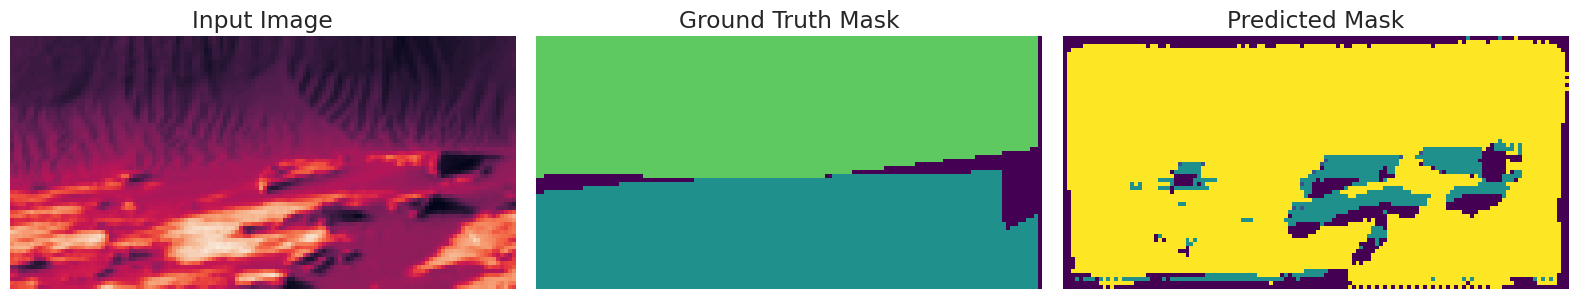


Epoch 46: val_mean_iou did not improve from 0.19013

Epoch 46: ReduceLROnPlateau reducing learning rate to 9.999999092680235e-13.
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 511ms/step - accuracy: 0.2393 - loss: 0.2033 - mean_iou: 0.1121 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-11
Epoch 47/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2396 - loss: 0.2055 - mean_iou: 0.1137
Epoch 47: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 484ms/step - accuracy: 0.2399 - loss: 0.2054 - mean_iou: 0.1137 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-12
Epoch 48/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2426 - loss: 0.2042 - mean_iou: 0.1154
Epoch 48: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 483ms/step - accuracy: 0.2427 - loss: 0.2041 - mean_iou: 0.1154 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

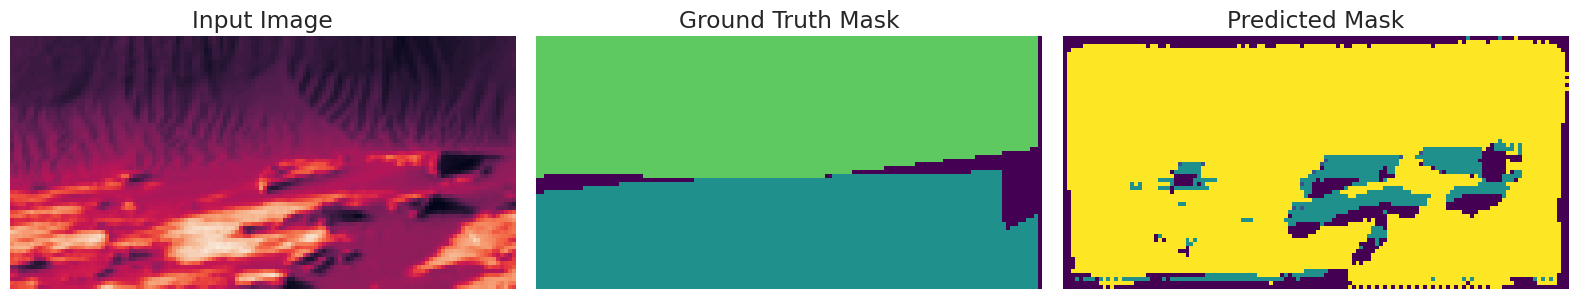


Epoch 51: val_mean_iou did not improve from 0.19013

Epoch 51: ReduceLROnPlateau reducing learning rate to 9.9999988758398e-14.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 509ms/step - accuracy: 0.2413 - loss: 0.2069 - mean_iou: 0.1147 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-12
Epoch 52/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2419 - loss: 0.2035 - mean_iou: 0.1147
Epoch 52: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 481ms/step - accuracy: 0.2420 - loss: 0.2035 - mean_iou: 0.1147 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-13
Epoch 53/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.2382 - loss: 0.2037 - mean_iou: 0.1126
Epoch 53: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 477ms/step - accuracy: 0.2384 - loss: 0.2036 - mean_iou: 0.1126 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate

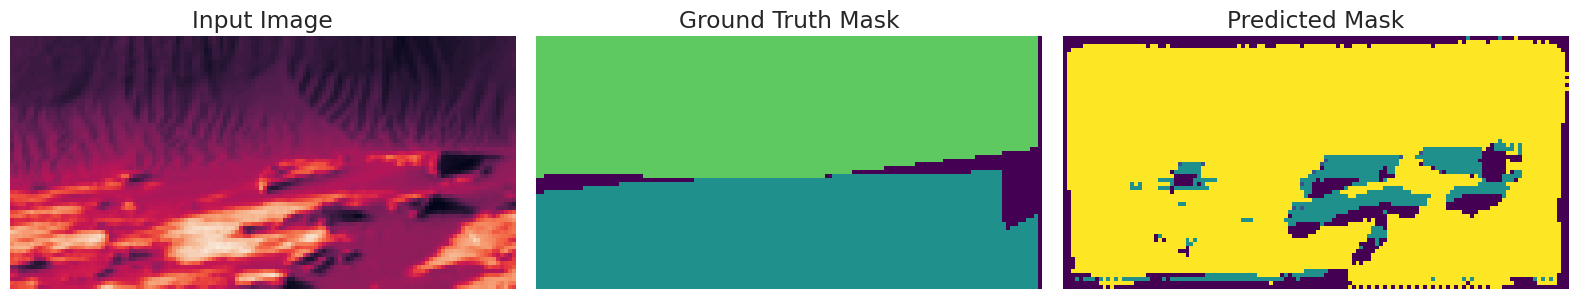


Epoch 56: val_mean_iou did not improve from 0.19013

Epoch 56: ReduceLROnPlateau reducing learning rate to 9.999999146890344e-15.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 500ms/step - accuracy: 0.2395 - loss: 0.2041 - mean_iou: 0.1122 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-13
Epoch 57/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.2394 - loss: 0.2035 - mean_iou: 0.1134
Epoch 57: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 479ms/step - accuracy: 0.2396 - loss: 0.2035 - mean_iou: 0.1134 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-14
Epoch 58/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2419 - loss: 0.2039 - mean_iou: 0.1146
Epoch 58: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 483ms/step - accuracy: 0.2420 - loss: 0.2039 - mean_iou: 0.1146 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

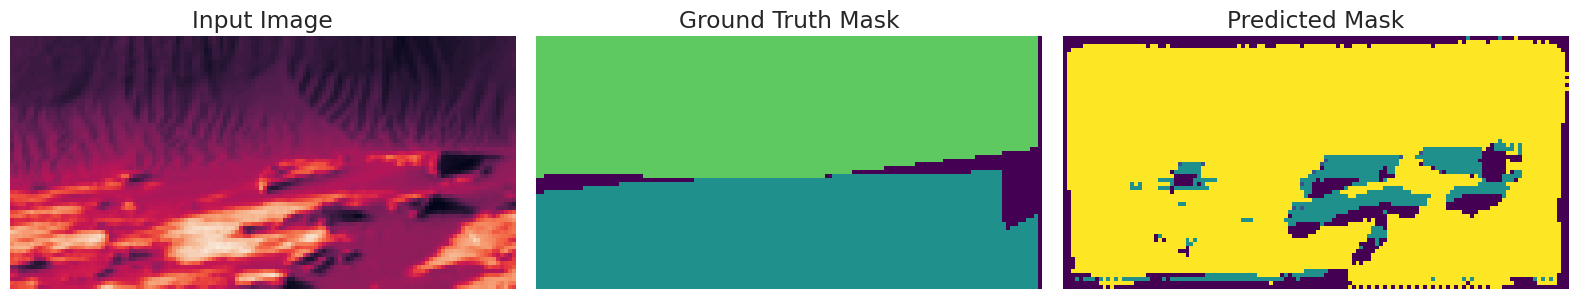


Epoch 61: val_mean_iou did not improve from 0.19013

Epoch 61: ReduceLROnPlateau reducing learning rate to 9.999998977483753e-16.
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 498ms/step - accuracy: 0.2397 - loss: 0.2046 - mean_iou: 0.1138 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-14
Epoch 62/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2411 - loss: 0.2042 - mean_iou: 0.1138
Epoch 62: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 480ms/step - accuracy: 0.2412 - loss: 0.2041 - mean_iou: 0.1138 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-15
Epoch 63/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.2432 - loss: 0.2036 - mean_iou: 0.1163
Epoch 63: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - accuracy: 0.2433 - loss: 0.2036 - mean_iou: 0.1163 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

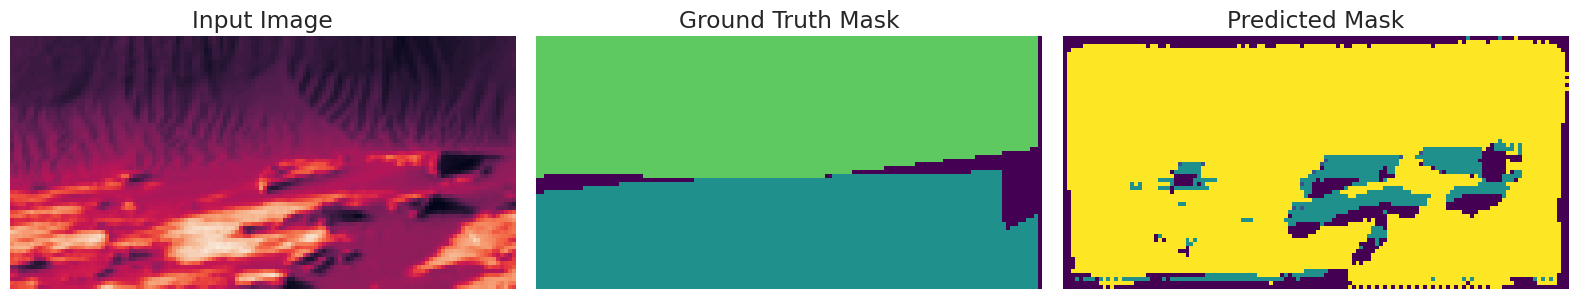


Epoch 66: val_mean_iou did not improve from 0.19013

Epoch 66: ReduceLROnPlateau reducing learning rate to 9.999998977483754e-17.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 498ms/step - accuracy: 0.2381 - loss: 0.2038 - mean_iou: 0.1129 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-15
Epoch 67/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2392 - loss: 0.2049 - mean_iou: 0.1143
Epoch 67: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - accuracy: 0.2394 - loss: 0.2048 - mean_iou: 0.1143 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-16
Epoch 68/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2401 - loss: 0.2055 - mean_iou: 0.1142
Epoch 68: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 481ms/step - accuracy: 0.2403 - loss: 0.2054 - mean_iou: 0.1142 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

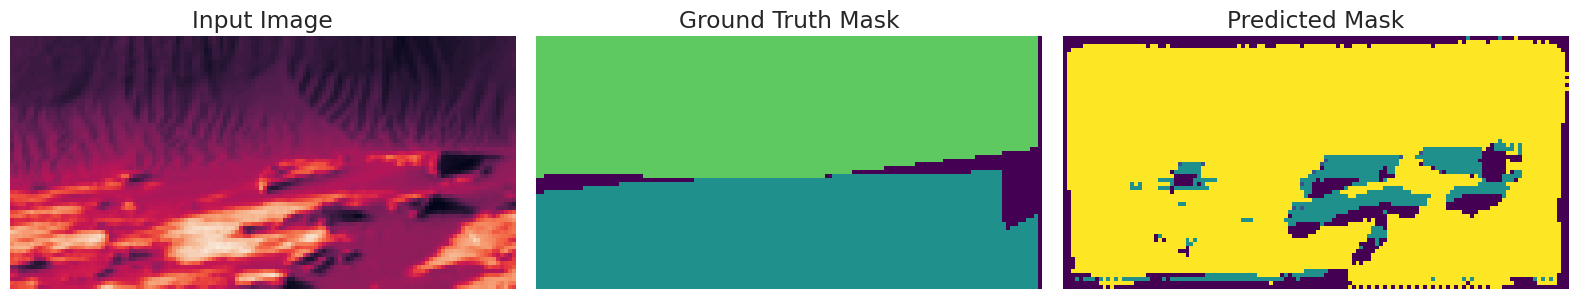


Epoch 71: val_mean_iou did not improve from 0.19013

Epoch 71: ReduceLROnPlateau reducing learning rate to 9.999998845134856e-18.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 497ms/step - accuracy: 0.2384 - loss: 0.2040 - mean_iou: 0.1131 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-16
Epoch 72/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2395 - loss: 0.2040 - mean_iou: 0.1137
Epoch 72: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step - accuracy: 0.2397 - loss: 0.2040 - mean_iou: 0.1137 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-17
Epoch 73/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2379 - loss: 0.2066 - mean_iou: 0.1128
Epoch 73: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 480ms/step - accuracy: 0.2381 - loss: 0.2065 - mean_iou: 0.1128 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

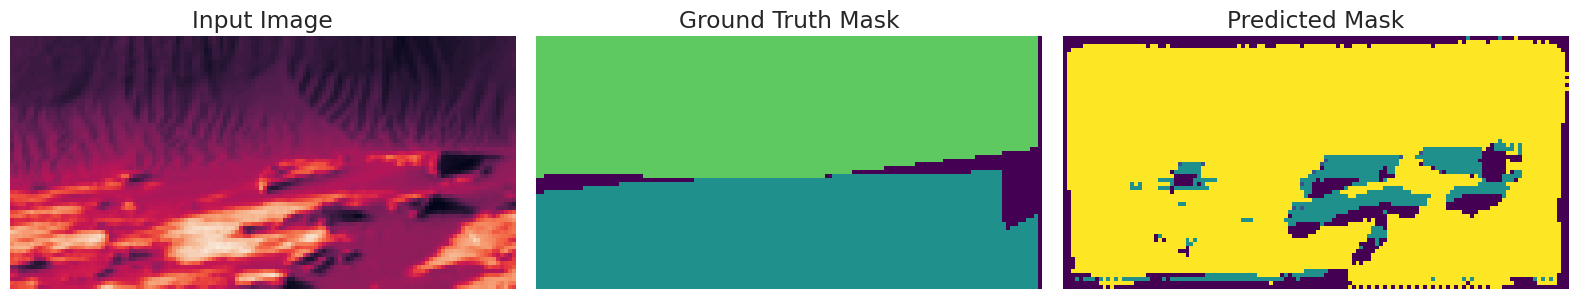


Epoch 76: val_mean_iou did not improve from 0.19013

Epoch 76: ReduceLROnPlateau reducing learning rate to 9.999999010570977e-19.
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 501ms/step - accuracy: 0.2384 - loss: 0.2033 - mean_iou: 0.1127 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-17
Epoch 77/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2403 - loss: 0.2050 - mean_iou: 0.1143
Epoch 77: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 480ms/step - accuracy: 0.2405 - loss: 0.2049 - mean_iou: 0.1143 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_rate: 1.0000e-18
Epoch 78/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2396 - loss: 0.2047 - mean_iou: 0.1130
Epoch 78: val_mean_iou did not improve from 0.19013
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - accuracy: 0.2398 - loss: 0.2046 - mean_iou: 0.1130 - val_accuracy: 0.2471 - val_loss: 0.2046 - val_mean_iou: 0.1077 - learning_ra

In [ ]:
att_model = tfk.models.load_model(
    'Models/Att_UNet_42.76.keras',
    compile=False,  # Non compila subito il modello
    custom_objects={
        'combined_loss': combined_loss,
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)


att_model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=combined_loss,  # Custom loss
    metrics=["accuracy", MeanIntersectionOverUnion(num_classes=NUM_CLASSES, labels_to_exclude=[0])]
)


history = att_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, viz_callback, checkpoint, reduceLROnPlateau],
    verbose=1
).history

# Calculate and print the final validation accuracy
final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'Att_UNet_'+str(final_val_meanIoU)+'.keras'
att_model.save('Models/' + model_filename)

# Delete the model to free up resources
del att_model

##Visualize model results

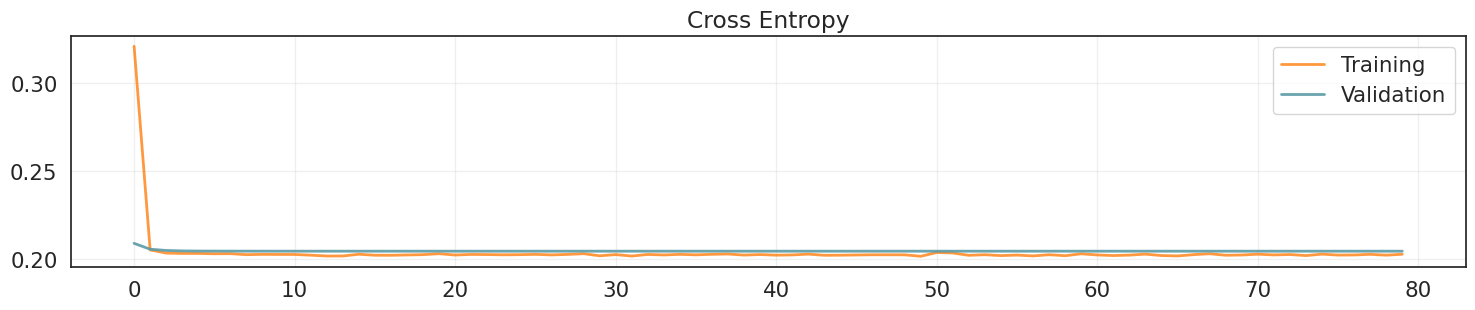

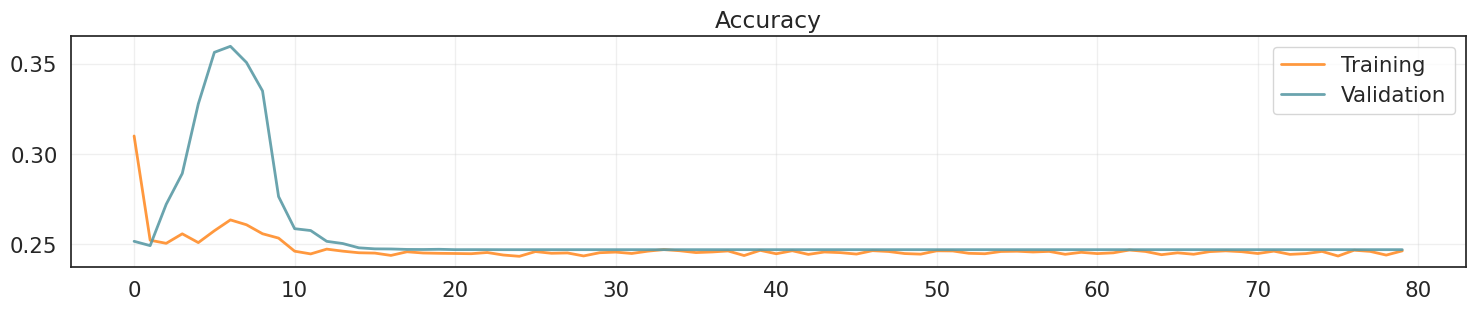

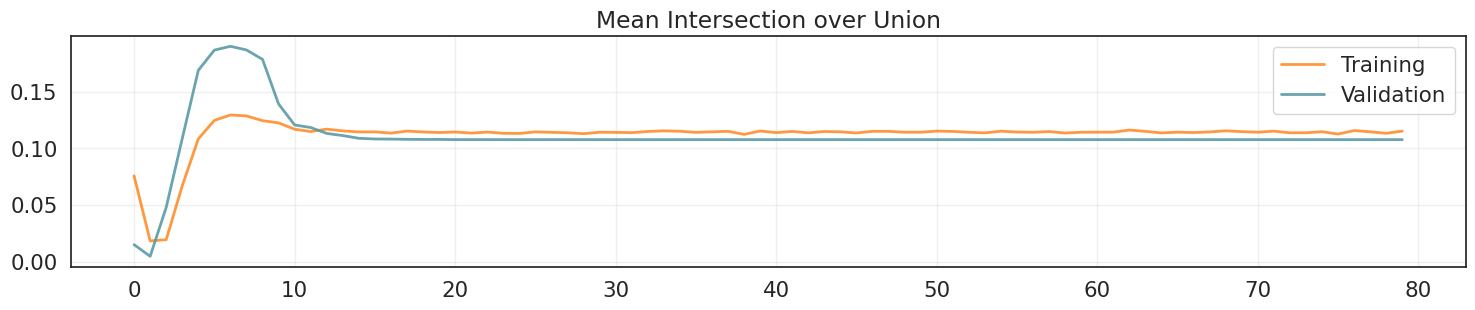

In [ ]:
# Plot and display training and validation loss
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation accuracy
plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot and display training and validation mean IoU
plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.




In [ ]:
data = np.load("Dataset/mars_for_students.npz")

X_test = data["test_set"]

In [ ]:
# If model_filename is not defined, load the most recent model from Google Drive
model_filename = "Models/Att_UNet_19.01.keras"
if "model_filename" not in globals() or model_filename is None:
    files = [f for f in os.listdir('.') if os.path.isfile(f) and f.startswith('model_') and f.endswith('.keras')]
    files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    if files:
        model_filename = files[0]
    else:
        raise FileNotFoundError("No model files found in the current directory.")

In [ ]:
'''
model = tfk.models.load_model(
    model_filename,
    compile=False,  # Non compila subito il modello
    custom_objects={
        'weighted_sparse_categorical_crossentropy': weighted_sparse_categorical_crossentropy,
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)
'''

model = tfk.models.load_model(
    model_filename,
    compile=False,  # Non compila subito il modello
    custom_objects={
        'combined_loss': combined_loss,
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)
"""
model = tfk.models.load_model(
    model_filename,
    compile=False,  # Non compila subito il modello
    custom_objects={
        'MeanIntersectionOverUnion': MeanIntersectionOverUnion
    }
)
"""
print(f"Model loaded from {model_filename}")

Model loaded from Models/Att_UNet_19.01.keras


In [ ]:
preds = model.predict(X_test)
preds = np.argmax(preds, axis=-1)
print(f"Predictions shape: {preds.shape}")

314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step
Predictions shape: (10022, 64, 128)


In [ ]:
def y_to_df(y) -> pd.DataFrame:
    """Converts segmentation predictions into a DataFrame format for Kaggle."""
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

In [ ]:
# Create and download the csv submission file
timestep_str = model_filename.replace("model_", "").replace(".keras", "")
submission_filename = f"submission_{timestep_str}.csv"
submission_df = y_to_df(preds)
submission_df.to_csv(submission_filename, index=False)

from google.colab import files
files.download(submission_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>